# **Project Name**    - **Startup Investment Analysis Using Shark Tank Data**

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name -** Bhoomi Gupta


# **Problem Statement and Project Background**

**Exploratory data analysis is an approach of analyzing data sets to summarize their main characteristics, using different data visualization methods like Matplotlib, Seaborn, Pandas etc. Shark Tank India has recently attracted all of our attentions in the last few months. I was busy analyzing the season where I have used the Kaggle Dataset.**



# **GitHub Link -**

Github Link:- https://github.com/Siddharth-94/EDA-On-Shark-Tank-India-Data.git

### Import Libraries

In [1]:
# Import Libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from scipy import stats
from babel.numbers import format_currency
from wordcloud import WordCloud, STOPWORDS
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px
pio.templates.default = "plotly_dark"
# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

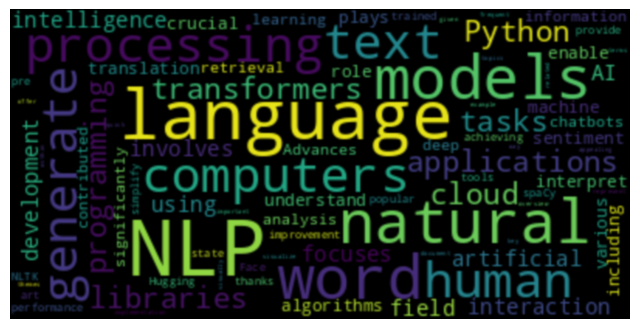

In [ ]:
# WordCloud Code Demonstration
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Example text data
text_data = """
Natural language processing (NLP) is a field of artificial intelligence (AI) that focuses on the interaction between computers and humans using natural language. It involves the development of algorithms and models to enable computers to understand, interpret, and generate human-like text.

NLP plays a crucial role in various applications, including machine translation, sentiment analysis, chatbots, and information retrieval. Advances in deep learning have significantly contributed to the improvement of NLP tasks, with models like transformers achieving state-of-the-art performance.

Python is a popular programming language for NLP tasks, thanks to libraries like NLTK, spaCy, and Hugging Face's Transformers. These libraries provide tools and pre-trained models that simplify the implementation of NLP applications.

Word clouds are a visually appealing way to represent the most frequent words in a given text. They offer a quick overview of the key themes and topics within a document. In this example, we generate a word cloud to visualize the important terms related to natural language processing and Python programming.
"""

# Create WordCloud object
wordcloud = WordCloud(stopwords=STOPWORDS, background_color='black').generate(text_data)

# Display the WordCloud using Matplotlib
plt.figure(figsize=(8, 8))
plt.imshow(wordcloud, interpolation='bicubic')
plt.axis('off')
plt.show()

### Dataset Loading

In [2]:
# Load Dataset

# Mounting Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Loading Dataset
shark_tank = pd.read_csv('/content/drive/MyDrive/Shark Tank India.csv')

## Exploring the Data

### Dataset First View

In [4]:
# Set the display options to show all columns
pd.set_option('display.max_columns', None)

In [5]:
# First Look

# Checking the first 5 rows of data
shark_tank.head()

,Season Number,Startup Name,Season Start,Season End,Episode Number,Episode Title,Anchor,Pitch Number,Industry,Business Description,Company Website,Number of Presenters,Male Presenters,Female Presenters,Transgender Presenters,Couple Presenters,Pitchers Average Age,Started in,Pitchers City,Pitchers State,Yearly Revenue,Monthly Sales,Gross Margin,Net Margin,Original Ask Amount,Original Offered Equity,Valuation Requested,Received Offer,Accepted Offer,Total Deal Amount,Total Deal Equity,Total Deal Debt,Debt Interest,Deal Valuation,Number of sharks in deal,Deal has conditions,Has Patents,Ashneer Investment Amount,Ashneer Investment Equity,Ashneer Debt Amount,Namita Investment Amount,Namita Investment Equity,Namita Debt Amount,Anupam Investment Amount,Anupam Investment Equity,Anupam Debt Amount,Vineeta Investment Amount,Vineeta Investment Equity,Vineeta Debt Amount,Aman Investment Amount,Aman Investment Equity,Aman Debt Amount,Peyush Investment Amount,Peyush Investment Equity,Peyush Debt Amount,Ghazal Investment Amount,Ghazal Investment Equity,Ghazal Debt Amount,Amit Investment Amount,Amit Investment Equity,Amit Debt Amount,Guest Investment Amount,Guest Investment Equity,Guest Debt Amount,Guest Name,Ashneer Present,Namita Present,Anupam Present,Vineeta Present,Aman Present,Peyush Present,Ghazal Present,Amit Present,Guest Present
0,1,BluePineFoods,20-Dec-21,04-Feb-22,1,Badlegi Business Ki Tasveer,Rannvijay Singh,1,Food,Frozen Momos,https://bluepinefoods.com/,3,2.0,1.0,NaN,0.0,Middle,2016.0,Delhi,Delhi,95.0,8.0,NaN,NaN,50.0,5.0,1000.0,1,1.0,75.0,16.00,NaN,NaN,469.0,3.0,NaN,NaN,25.0,5.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.0,5.33,NaN,25.0,5.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
1,1,BoozScooters,20-Dec-21,04-Feb-22,1,Badlegi Business Ki Tasveer,Rannvijay Singh,2,Vehicles/Electrical Vehicles,Renting e-bike for mobility in private spaces,https://www.boozup.net/,1,1.0,NaN,NaN,0.0,Young,2017.0,Ahmedabad,Gujarat,4.0,0.4,NaN,NaN,40.0,15.0,267.0,1,1.0,40.0,50.00,NaN,NaN,80.0,2.0,NaN,NaN,20.0,25.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,25.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
2,1,HeartUpMySleeves,20-Dec-21,04-Feb-22,1,Badlegi Business Ki Tasveer,Rannvijay Singh,3,Beauty/Fashion,Detachable Sleeves,https://heartupmysleeves.com/,1,NaN,1.0,NaN,0.0,Young,2021.0,Delhi,Delhi,NaN,2.0,NaN,NaN,25.0,10.0,250.0,1,1.0,25.0,30.00,NaN,NaN,83.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.5,15.0,NaN,12.5,15.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
3,1,TagzFoods,20-Dec-21,04-Feb-22,2,"Insaan, Ideas Aur Sapne",Rannvijay Singh,4,Food,Healthy Potato Chips Snacks,https://tagzfoods.com/,2,2.0,NaN,NaN,0.0,Middle,2019.0,Bangalore,Karnataka,700.0,NaN,48.0,NaN,70.0,1.0,7000.0,1,1.0,70.0,2.75,NaN,NaN,2545.0,1.0,NaN,NaN,70.0,2.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
4,1,HeadAndHeart,20-Dec-21,04-Feb-22,2,"Insaan, Ideas Aur Sapne",Rannvijay Singh,5,Education,Brain Development Course,https://thehnh.in/,4,1.0,3.0,NaN,1.0,Middle,2015.0,Patiala,Punjab,30.0,NaN,NaN,NaN,50.0,5.0,1000.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN


In [6]:
# Checking the bottom 5 rows of the data
shark_tank.tail()

,Season Number,Startup Name,Season Start,Season End,Episode Number,Episode Title,Anchor,Pitch Number,Industry,Business Description,Company Website,Number of Presenters,Male Presenters,Female Presenters,Transgender Presenters,Couple Presenters,Pitchers Average Age,Started in,Pitchers City,Pitchers State,Yearly Revenue,Monthly Sales,Gross Margin,Net Margin,Original Ask Amount,Original Offered Equity,Valuation Requested,Received Offer,Accepted Offer,Total Deal Amount,Total Deal Equity,Total Deal Debt,Debt Interest,Deal Valuation,Number of sharks in deal,Deal has conditions,Has Patents,Ashneer Investment Amount,Ashneer Investment Equity,Ashneer Debt Amount,Namita Investment Amount,Namita Investment Equity,Namita Debt Amount,Anupam Investment Amount,Anupam Investment Equity,Anupam Debt Amount,Vineeta Investment Amount,Vineeta Investment Equity,Vineeta Debt Amount,Aman Investment Amount,Aman Investment Equity,Aman Debt Amount,Peyush Investment Amount,Peyush Investment Equity,Peyush Debt Amount,Ghazal Investment Amount,Ghazal Investment Equity,Ghazal Debt Amount,Amit Investment Amount,Amit Investment Equity,Amit Debt Amount,Guest Investment Amount,Guest Investment Equity,Guest Debt Amount,Guest Name,Ashneer Present,Namita Present,Anupam Present,Vineeta Present,Aman Present,Peyush Present,Ghazal Present,Amit Present,Guest Present
316,2,GODESi,02-Jan-23,10-Mar-23,51,Gateway To Shark Tank India,Rahul Dua,317,Food,Handmade lollipops,https://godesi.in/,2,1.0,1.0,NaN,0.0,Middle,NaN,Bangalore,Karnataka,-1.0,270.0,NaN,NaN,90.0,0.5,18000.0,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,NaN,NaN,1.0,1.0
317,2,TAC,02-Jan-23,10-Mar-23,51,Gateway To Shark Tank India,Rahul Dua,318,Beauty/Fashion,"ayurveda co for glowing skin, makeup & open pores",https://theayurvedaco.com/,2,1.0,1.0,NaN,1.0,Middle,NaN,Mumbai,Maharashtra,-1.0,NaN,NaN,NaN,150.0,0.5,30000.0,1,1.0,81.0,1.0,69.0,12.0,8100.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.5,0.5,34.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.5,0.5,34.5,Vikas,NaN,1.0,NaN,1.0,1.0,NaN,NaN,1.0,1.0
318,2,Naara-Aaba,02-Jan-23,10-Mar-23,51,Gateway To Shark Tank India,Rahul Dua,319,Liquor/Beverages,pears and plum wine,https://www.naaraaaba.com/,2,1.0,1.0,NaN,1.0,Middle,2017.0,Ziro,Arunachal Pradesh,NaN,NaN,50.0,18.0,75.0,2.5,3000.0,1,1.0,50.0,5.0,25.0,10.0,1000.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.0,2.5,12.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.0,2.5,12.5,Vikas,NaN,1.0,NaN,1.0,1.0,NaN,NaN,1.0,1.0
319,2,StyloBug,02-Jan-23,10-Mar-23,51,Gateway To Shark Tank India,Rahul Dua,320,Beauty/Fashion,Girls Dresses Online,https://stylobug.com/,2,1.0,1.0,NaN,NaN,Middle,NaN,Delhi,Delhi,1400.0,46.0,NaN,18.0,80.0,2.0,4000.0,1,1.0,80.0,10.0,NaN,NaN,800.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,NaN,NaN,1.0,1.0
320,2,ZenOnco,02-Jan-23,10-Mar-23,0,Unseen,Rahul Dua,321,Medical/Health,saving lives from cancer,https://zenonco.io/,2,1.0,1.0,NaN,0.0,Middle,NaN,Jodhpur,Rajasthan,-1.0,21.0,NaN,NaN,100.0,1.0,10000.0,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,NaN,NaN,1.0,1.0


In [ ]:
# Dataset Columns
shark_tank.columns

Index(['Season Number', 'Startup Name', 'Season Start', 'Season End',
       'Episode Number', 'Episode Title', 'Anchor', 'Pitch Number', 'Industry',
       'Business Description', 'Company Website', 'Number of Presenters',
       'Male Presenters', 'Female Presenters', 'Transgender Presenters',
       'Couple Presenters', 'Pitchers Average Age', 'Started in',
       'Pitchers City', 'Pitchers State', 'Yearly Revenue', 'Monthly Sales',
       'Gross Margin', 'Net Margin', 'Original Ask Amount',
       'Original Offered Equity', 'Valuation Requested', 'Received Offer',
       'Accepted Offer', 'Total Deal Amount', 'Total Deal Equity',
       'Total Deal Debt', 'Debt Interest', 'Deal Valuation',
       'Number of sharks in deal', 'Deal has conditions', 'Has Patents',
       'Ashneer Investment Amount', 'Ashneer Investment Equity',
       'Ashneer Debt Amount', 'Namita Investment Amount',
       'Namita Investment Equity', 'Namita Debt Amount',
       'Anupam Investment Amount', 'Anupam I

### Dataset Information

In [ ]:
# Dataset Info

# Data information. Inspecting each columns and its dtype
shark_tank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 74 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Season Number              321 non-null    int64  
 1   Startup Name               321 non-null    object 
 2   Season Start               321 non-null    object 
 3   Season End                 321 non-null    object 
 4   Episode Number             321 non-null    int64  
 5   Episode Title              321 non-null    object 
 6   Anchor                     321 non-null    object 
 7   Pitch Number               321 non-null    int64  
 8   Industry                   321 non-null    object 
 9   Business Description       321 non-null    object 
 10  Company Website            310 non-null    object 
 11  Number of Presenters       321 non-null    int64  
 12  Male Presenters            282 non-null    float64
 13  Female Presenters          150 non-null    float64

In [ ]:
# Dataset Describe

# Checking statistical data on numerical columns
shark_tank.describe()

,Season Number,Episode Number,Pitch Number,Number of Presenters,Male Presenters,Female Presenters,Transgender Presenters,Couple Presenters,Started in,Yearly Revenue,...,Guest Debt Amount,Ashneer Present,Namita Present,Anupam Present,Vineeta Present,Aman Present,Peyush Present,Ghazal Present,Amit Present,Guest Present
count,321.000000,321.000000,321.000000,321.000000,282.000000,150.000000,3.0,316.000000,184.000000,135.000000,...,2.000000,99.0,276.0,282.0,187.0,268.0,233.0,26.0,83.0,5.0
mean,1.526480,21.482866,161.000000,2.077882,1.719858,1.193333,1.0,0.186709,2018.472826,353.303704,...,23.500000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
std,0.500078,14.702695,92.808944,0.846044,0.866269,0.428775,0.0,0.390296,2.495750,915.969002,...,15.556349,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,2005.000000,-1.000000,...,12.500000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
25%,1.000000,9.000000,81.000000,2.000000,1.000000,1.000000,1.0,0.000000,2017.000000,0.000000,...,18.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
50%,2.000000,21.000000,161.000000,2.000000,2.000000,1.000000,1.0,0.000000,2019.000000,100.000000,...,23.500000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
75%,2.000000,33.000000,241.000000,2.000000,2.000000,1.000000,1.0,0.000000,2020.000000,245.000000,...,29.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
max,2.000000,51.000000,321.000000,6.000000,6.000000,3.000000,1.0,1.000000,2022.000000,7200.000000,...,34.500000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
shark_tank.shape

(321, 74)

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
duplicate_values_count = len(shark_tank[shark_tank.duplicated()])

print("Number of duplicate values:", duplicate_values_count)

Number of duplicate values: 0


#### Missing Values/Null Values

In [ ]:
# Finding Null Values Count
shark_tank.isnull().sum().sort_values(ascending=False)

Ghazal Debt Amount         321
Guest Name                 319
Guest Debt Amount          319
Guest Investment Equity    319
Guest Investment Amount    319
                          ... 
Episode Title                0
Anchor                       0
Pitch Number                 0
Industry                     0
Season Number                0
Length: 74, dtype: int64

Text(0.5, 1.0, 'Places of missing values in the columns')

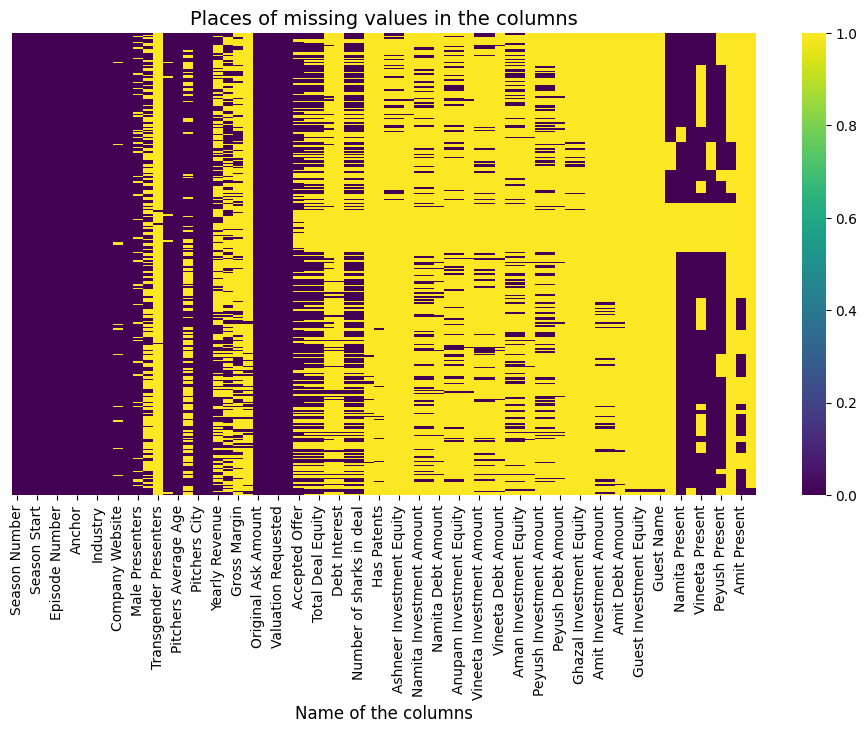

In [ ]:
# Visualizing the missing values
# Creating heatmap for null values
plt.figure(figsize = (12,6))
sns.heatmap(shark_tank.isnull(), yticklabels = False, cbar = True, cmap = 'viridis')
plt.xlabel("Name of the columns", fontsize = 12)
plt.title("Places of missing values in the columns", fontsize = 14)

## **Correlation Matrix**

In [ ]:
shark_tank.corr(method = 'pearson').T.round(2).style.background_gradient(cmap='viridis')

,Season Number,Episode Number,Pitch Number,Number of Presenters,Male Presenters,Female Presenters,Transgender Presenters,Couple Presenters,Started in,Yearly Revenue,Monthly Sales,Gross Margin,Net Margin,Original Ask Amount,Original Offered Equity,Valuation Requested,Received Offer,Accepted Offer,Total Deal Amount,Total Deal Equity,Total Deal Debt,Debt Interest,Deal Valuation,Number of sharks in deal,Has Patents,Ashneer Investment Amount,Ashneer Investment Equity,Ashneer Debt Amount,Namita Investment Amount,Namita Investment Equity,Namita Debt Amount,Anupam Investment Amount,Anupam Investment Equity,Anupam Debt Amount,Vineeta Investment Amount,Vineeta Investment Equity,Vineeta Debt Amount,Aman Investment Amount,Aman Investment Equity,Aman Debt Amount,Peyush Investment Amount,Peyush Investment Equity,Peyush Debt Amount,Ghazal Investment Amount,Ghazal Investment Equity,Ghazal Debt Amount,Amit Investment Amount,Amit Investment Equity,Amit Debt Amount,Guest Investment Amount,Guest Investment Equity,Guest Debt Amount,Ashneer Present,Namita Present,Anupam Present,Vineeta Present,Aman Present,Peyush Present,Ghazal Present,Amit Present,Guest Present
Season Number,1.000000,0.390000,0.860000,0.010000,0.040000,0.070000,nan,-0.070000,0.090000,-0.030000,0.280000,0.000000,nan,-0.050000,-0.250000,0.090000,0.090000,0.190000,0.110000,-0.410000,0.150000,nan,0.270000,-0.150000,nan,nan,nan,nan,0.140000,-0.170000,0.210000,0.340000,-0.150000,0.360000,0.280000,-0.390000,-0.110000,0.170000,-0.350000,-0.260000,0.160000,-0.360000,0.480000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Episode Number,0.390000,1.000000,0.630000,-0.000000,0.070000,0.010000,nan,-0.070000,-0.030000,0.120000,0.150000,-0.040000,-0.080000,-0.040000,-0.140000,0.070000,0.000000,0.060000,0.040000,-0.160000,-0.050000,0.290000,0.110000,0.020000,nan,-0.270000,-0.180000,1.000000,-0.090000,-0.070000,-0.290000,-0.080000,-0.190000,-0.770000,0.040000,-0.410000,-0.280000,0.080000,-0.180000,-0.270000,0.080000,-0.040000,0.190000,-0.420000,0.030000,nan,-0.050000,-0.310000,0.950000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Pitch Number,0.860000,0.630000,1.000000,-0.000000,0.030000,-0.020000,nan,-0.070000,0.110000,0.030000,0.270000,-0.030000,-0.090000,-0.070000,-0.220000,0.090000,-0.070000,0.080000,0.100000,-0.390000,0.090000,0.310000,0.260000,-0.100000,nan,-0.260000,-0.160000,1.000000,0.060000,-0.160000,-0.120000,0.230000,-0.200000,-0.020000,0.220000,-0.490000,-0.240000,0.160000,-0.340000,-0.340000,0.170000,-0.330000,0.460000,0.100000,-0.260000,nan,-0.050000,-0.310000,0.950000,-1.000000,1.000000,-1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan
Number of Presenters,0.010000,-0.000000,-0.000000,1.000000,0.760000,0.320000,nan,0.140000,-0.040000,-0.050000,0.040000,-0.170000,0.080000,-0.070000,-0.150000,0.040000,0.060000,-0.020000,0.080000,-0.260000,0.290000,0.270000,0.150000,0.030000,nan,-0.080000,-0.280000,nan,-0.090000,-0.110000,-0.250000,0.010000,-0.290000,nan,0.190000,-0.230000,-0.320000,0.130000,0.030000,0.490000,0.090000,-0.320000,0.500000,0.280000,-0.450000,nan,-0.290000,-0.070000,0.800000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Male Presenters,0.040000,0.070000,0.030000,0.760000,1.000000,-0.020000,nan,-0.340000,0.000000,-0.040000,0.060000,-0.100000,-0.150000,-0.040000,-0.170000,0.040000,0.030000,0.070000,0.100000,-0.150000,0.360000,0.150000,0.210000,0.050000,nan,-0.170000,-0.170000,1.000000,0.000000,-0.170000,0.250000,-0.010000,-0.230000,0.460000,-0.080000,-0.020000,0.160000,0.240000,0.060000,0.330000,0.070000,-0.200000,0.380000,0.060000,-0.280000,nan,-0.200000,-0.370000,0.870000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Female Presenters,0.070000,0.010000,-0.020000,0.320000,-0.020000,1.000000,nan,-0.090000,0.040000,-0.150000,-0.060000,0.080000,0.190000,-0.050000,0.010000,0.080000,0.130000,-0.100000,-0.170000,-0.000000,-0.140000,-0.340000,-0.070000,-0.150000,nan,nan,nan,nan,-0.160000,-0.140000,-0.590000,-0.070000,0.000000,nan,0.010000,-0.120000,-0.

## ***EDA (Exploratory Data Analysis)***

## **Season 1 & 2** - Shark Tank India

In [ ]:
shark_tank['Season Number'].value_counts()

2    169
1    152
Name: Season Number, dtype: int64

In [ ]:
print(shark_tank['Season Number'].max(), "seasons \n")
print(shark_tank['Episode Number'].max(), "episodes \n")
print(shark_tank['Pitch Number'].max(), "startup companies came for pitching \n")

2 seasons 

51 episodes 

321 startup companies came for pitching 



## **Distribution of Cities from which Pitchers came**

In [ ]:
print(shark_tank['Pitchers City'].value_counts().head(20))

Mumbai         56
Delhi          44
Bangalore      32
Pune           20
Ahmedabad      19
Gurgaon        15
Hyderabad      12
Kolkata        12
Noida           7
Jaipur          7
Chennai         6
Surat           6
Ludhiana        4
Thane           3
Indore          3
Goa             3
Gandhinagar     3
Nagpur          3
Jammu           2
Lucknow         2
Name: Pitchers City, dtype: int64


Text(0.5, 1.0, 'Pitchers Cities Count')

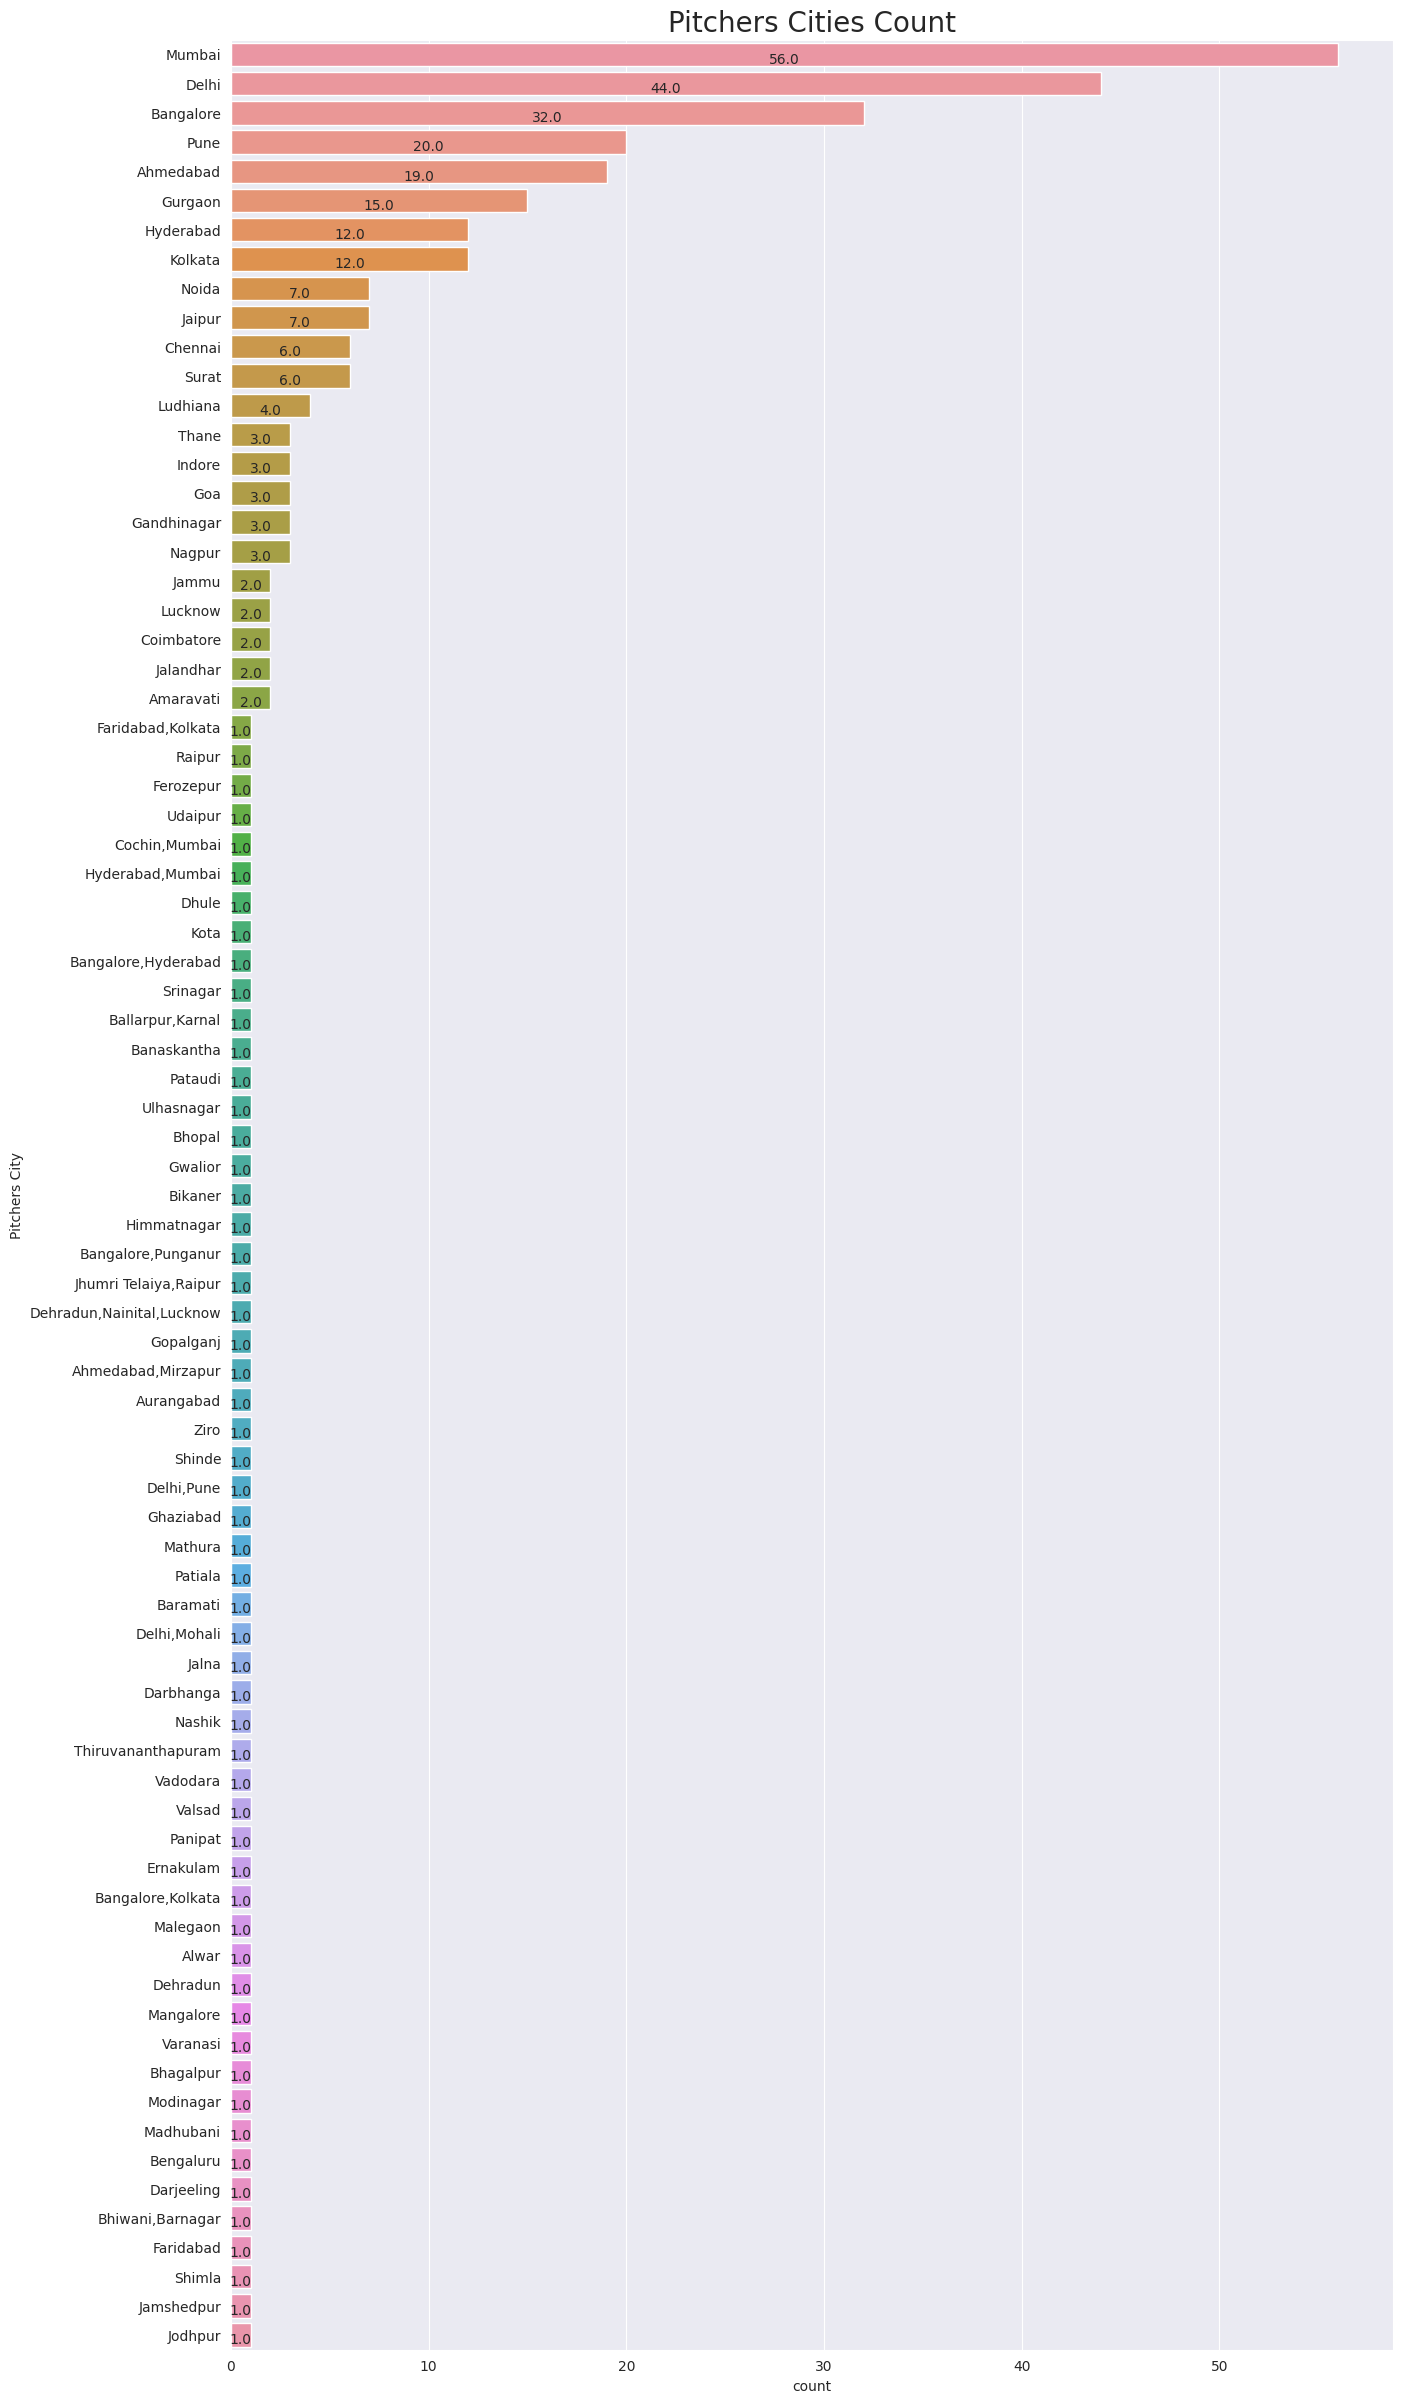

In [ ]:
plt.figure(figsize=(15,30))
ax = sns.countplot(data=shark_tank,y='Pitchers City', orient='h',order=shark_tank['Pitchers City'].value_counts().index)
for p in ax.patches:
    ax.annotate(f'{p.get_width()}', (p.get_x() + p.get_width() / 2, p.get_y() + p.get_height()), ha='center', va='bottom')
plt.title('Pitchers Cities Count',size=20)

## **Year in which Startups began their operation**

In [ ]:
print(shark_tank['Started in'].value_counts(),'\n')

2019.0    38
2020.0    31
2021.0    27
2018.0    26
2017.0    22
2016.0    18
2022.0     9
2015.0     4
2014.0     4
2005.0     1
2013.0     1
2012.0     1
2006.0     1
2010.0     1
Name: Started in, dtype: int64 



Text(0.5, 1.0, 'Startup Commencement Year')

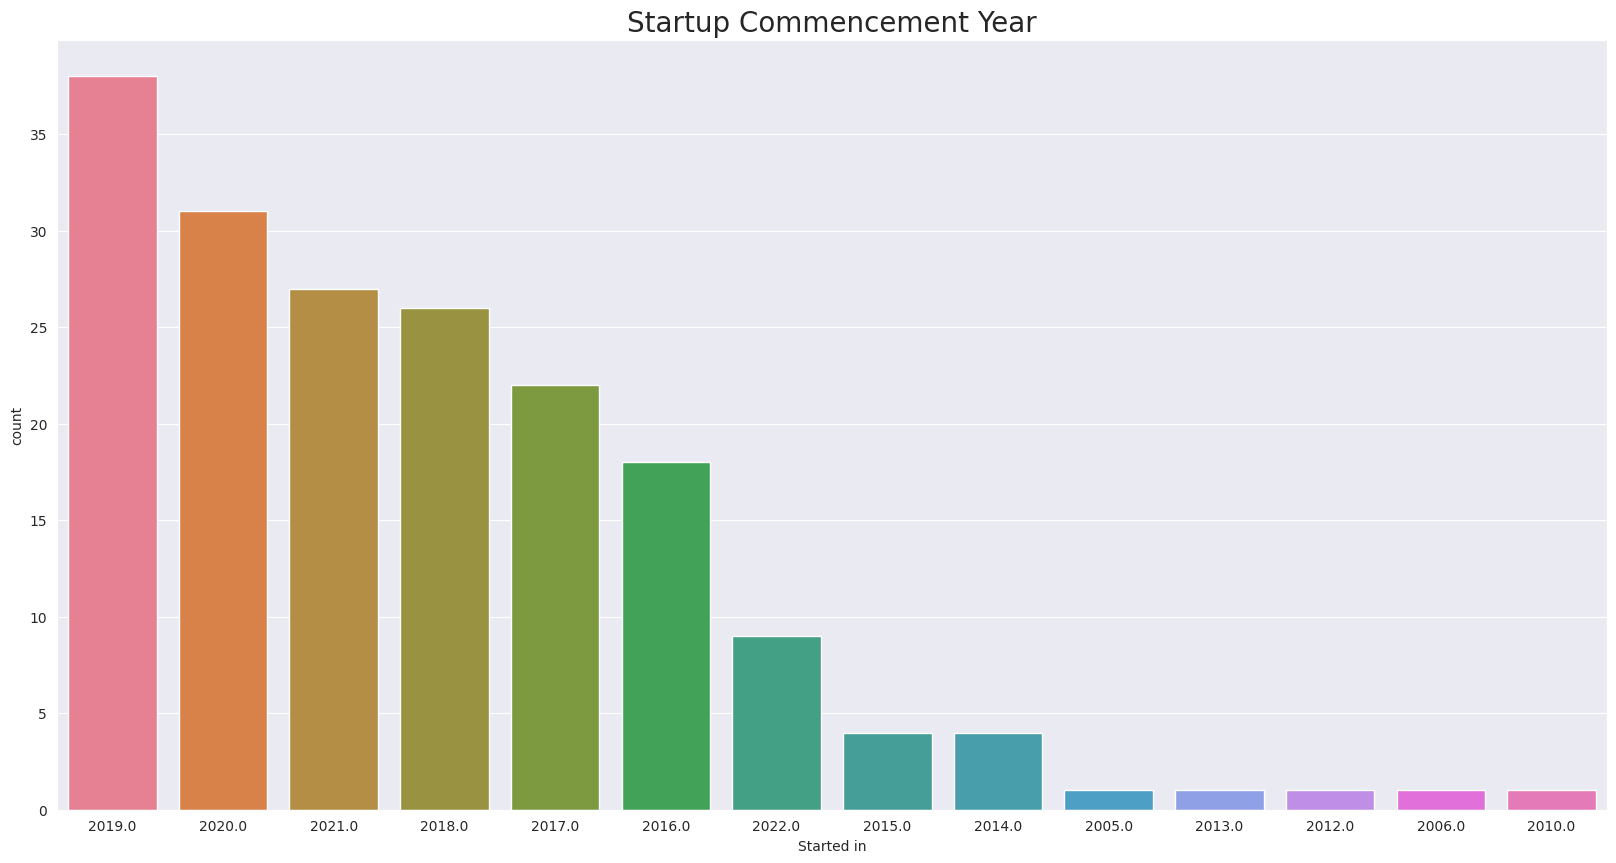

In [ ]:
plt.figure(figsize=(20,10))
sns.countplot(data=shark_tank,x='Started in', palette="husl", order=shark_tank['Started in'].value_counts().index)
plt.title('Startup Commencement Year',size=20)

## **Distribution of States from which Pitchers came**

In [ ]:
print(shark_tank['Pitchers State'].value_counts())

Maharashtra                  92
Delhi                        44
Karnataka                    34
Gujarat                      32
Haryana                      18
Uttar Pradesh                13
West Bengal                  13
Rajasthan                    12
Telangana                    12
Tamil Nadu                    8
Punjab                        8
Madhya Pradesh                5
Bihar                         4
Jammu & Kashmir               3
Goa                           3
Kerala                        2
Kerala,Maharashtra            1
Uttarakhand,Uttar Pradesh     1
Gujarat,Uttar Pradesh         1
Jharkhand,Chhattisgarh        1
Karnataka,Andhra Pradesh      1
Haryana,Maharashtra           1
Chhattisgarh                  1
Haryana,West Bengal           1
Uttarakhand                   1
Telangana,Maharashtra         1
Karnataka,Telangana           1
Jharkhand                     1
Himachal Pradesh              1
Haryana,Madhya Pradesh        1
Delhi,Maharashtra             1
Karnatak

Text(0.5, 1.0, 'Startup Commencement Year')

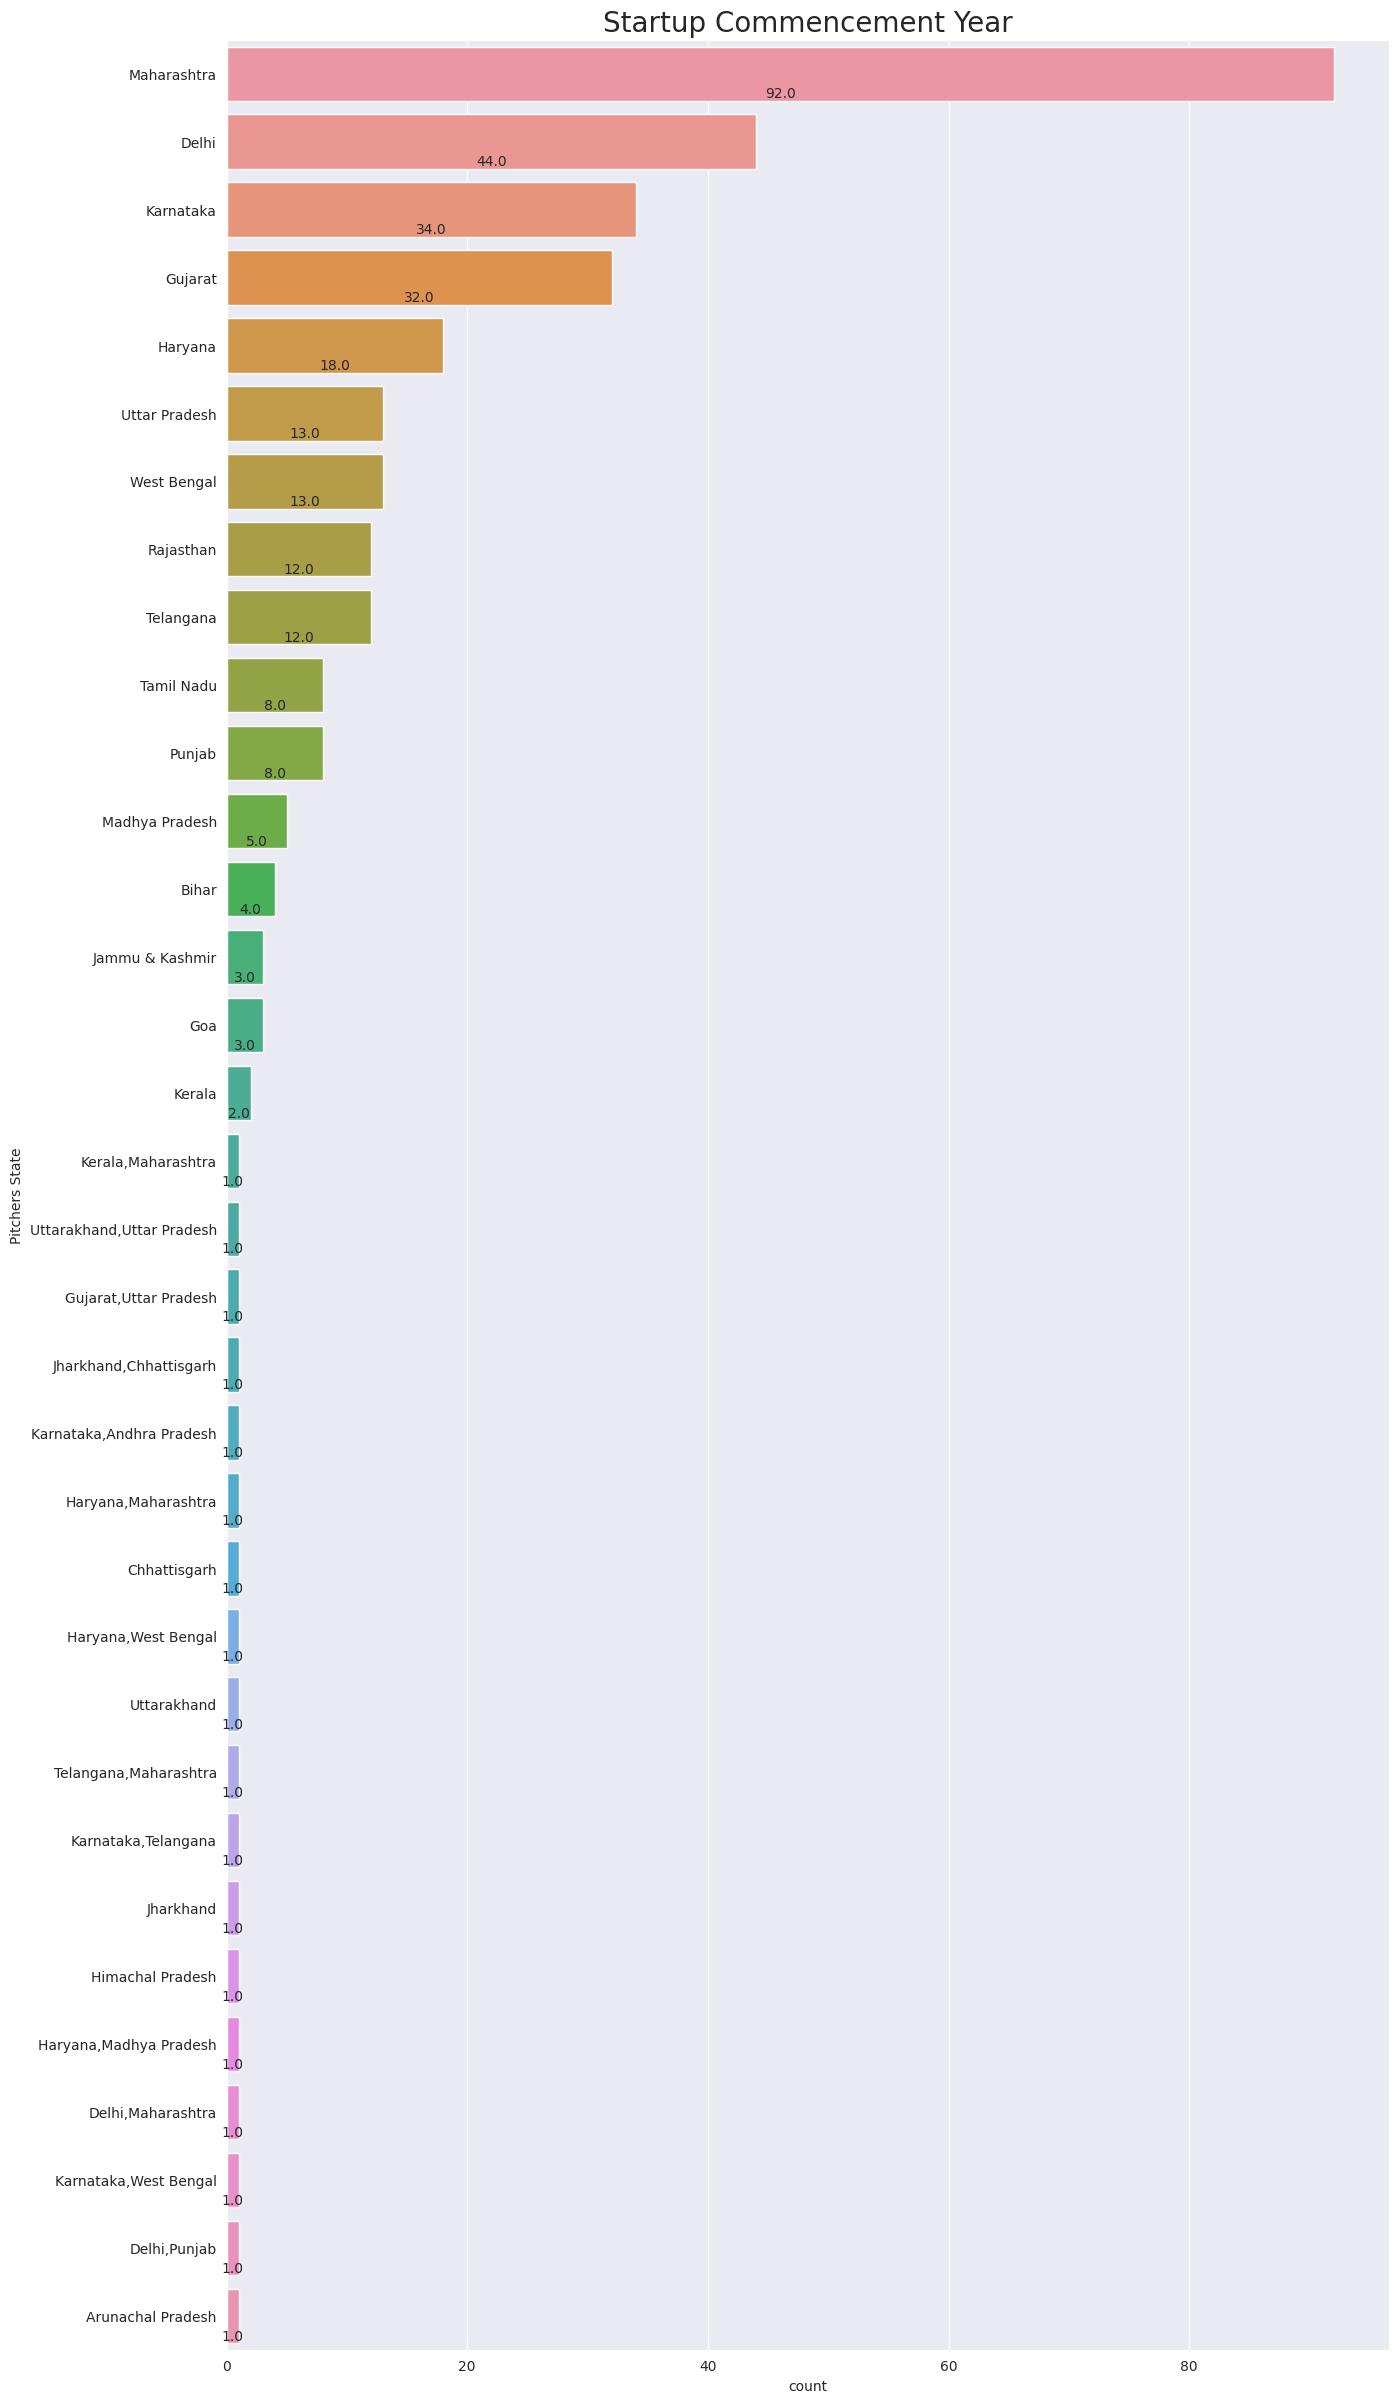

In [ ]:
plt.figure(figsize=(15,30))
ax = sns.countplot(data=shark_tank,y='Pitchers State', orient='h',order=shark_tank['Pitchers State'].value_counts().index)
for p in ax.patches:
    ax.annotate(f'{p.get_width()}', (p.get_x() + p.get_width() / 2, p.get_y() + p.get_height()), ha='center', va='bottom')
plt.title('Startup Commencement Year',size=20)

## **Distribution of different Industries that came for pitching**

In [ ]:
print(shark_tank['Industry'].value_counts())

Food                            82
Beauty/Fashion                  58
Manufacturing                   38
Services                        28
Technology/Software             26
Medical/Health                  24
Vehicles/Electrical Vehicles    13
Furnishing/Household            13
Education                        9
Sports                           7
Liquor/Beverages                 7
Animal/Pets                      5
Electronics                      4
Agriculture                      3
Hardware                         2
Entertainment                    2
Name: Industry, dtype: int64


In [ ]:
tmp = shark_tank['Industry'].value_counts().sort_values(ascending=True)
fig = px.bar(tmp, x="Industry", title="<b> Different Industries that came in Shark Tank India </b>", color = 'Industry', template='simple_white', text=tmp)
fig.show()

## **Gender Wise Distribution of Entrepreneurs**

In [ ]:
print("Total pitchers -", int(shark_tank['Number of Presenters'].sum()), "\n")

print("Total Male pitchers -", int(shark_tank['Male Presenters'].sum()), "\n")

print("Total female pitchers -", int(shark_tank['Female Presenters'].sum()), "\n")

print("Male entrepreneurs percentage - ", round(shark_tank['Male Presenters'].sum()/shark_tank['Number of Presenters'].sum()*100,2), "%\n", sep='')
print("Female entrepreneurs percentage - ", round(shark_tank['Female Presenters'].sum()/shark_tank['Number of Presenters'].sum()*100,2), "%\n", sep='')
print("Couple entrepreneurs percentage - ", round(shark_tank.loc[shark_tank['Couple Presenters']==1]['Couple Presenters'].sum()/shark_tank['Number of Presenters'].sum()*100,2), "% (data incomplete)\n", sep='')

Total pitchers - 667 

Total Male pitchers - 485 

Total female pitchers - 179 

Male entrepreneurs percentage - 72.71%

Female entrepreneurs percentage - 26.84%

Couple entrepreneurs percentage - 8.85% (data incomplete)



## **Top 10 Highest Yearly Revenue of the brands**

In [ ]:
print(shark_tank.groupby('Startup Name')['Yearly Revenue'].max().nlargest(10))

Startup Name
FrenchCrown          7200.0
Rubans               5100.0
Toyshine             4500.0
GuardianGears        2500.0
GunjanAppsStudios    2400.0
UnStop               1600.0
StyloBug             1400.0
RaisingSuperstars    1300.0
DesmondJi            1200.0
Eume                 1200.0
Name: Yearly Revenue, dtype: float64


In [ ]:
tmpdf = shark_tank.sort_values('Yearly Revenue', ascending=False)[0:10]
fig = px.bar(tmpdf, x="Startup Name", y='Yearly Revenue', color="Startup Name", template='plotly', title="Highest Revenue Start-ups", text=tmpdf['Yearly Revenue'])
fig.show()

## **Top 10 highest Gross Margin of different brands**

In [ ]:
# DataFrame which shows the Top 10 Start-ups which have the highest Gross Margin
shark_tank[['Startup Name','Gross Margin']].sort_values(by='Gross Margin',ascending=False).head(10)

,Startup Name,Gross Margin
69,Poo-de-Cologne,150.0
33,Farda,115.0
45,Cocofit,95.0
230,UnStop,90.0
256,MidNightAngelsByPC,83.0
195,Pflow,80.0
225,LeafyAffair,80.0
201,ekatra,80.0
291,oyehappy,80.0
34,Auli,80.0


In [ ]:
# Visualization Code
highest_gross_margin = shark_tank[['Startup Name','Gross Margin']].sort_values(by='Gross Margin',ascending=False).head(10)
fig = px.bar(highest_gross_margin, x="Startup Name", y='Gross Margin', color="Startup Name", template='plotly', title="Highest Gross Margins Start-ups", text=highest_gross_margin['Gross Margin'])
fig.show()

## **How many accepted or rejected sharks offers?**

In [ ]:
shark_tank['Accepted Offer'].value_counts()

1.0    176
0.0     41
Name: Accepted Offer, dtype: int64

In [ ]:
# Numbers of Pithers who accepted/rejected shark's offer
print(f"{shark_tank['Accepted Offer'].value_counts().iloc[0]} Pitchers accepted the shark's offer.")
print(f"{shark_tank['Accepted Offer'].value_counts().iloc[1]} Pitchers rejected the shark's offer.")

176 Pitchers accepted the shark's offer.
41 Pitchers rejected the shark's offer.


<Axes: xlabel='Accepted Offer', ylabel='count'>

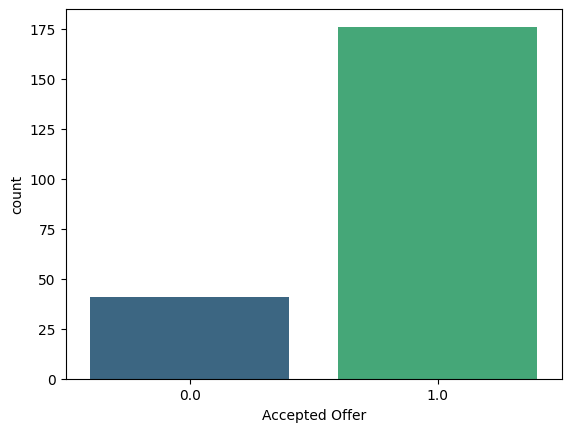

In [ ]:
# Visualization Code
sns.countplot(data=shark_tank,x='Accepted Offer',palette='viridis')

## **Startup Companies who rejected shark's offer**

In [ ]:
shark_tank[shark_tank['Accepted Offer'] == 0][['Season Number','Startup Name','Business Description',
                                               'Original Ask Amount','Original Offered Equity',
                                               'Valuation Requested',]]

,Season Number,Startup Name,Business Description,Original Ask Amount,Original Offered Equity,Valuation Requested
6,1,qZenseLabs,Food Freshness Detector,100.0,0.25,40000.000000
19,1,Torch-it,Gadgets for visually impaired people,75.0,1.00,7500.000000
21,1,LaKheerDeli,Kheer in variety of flavors,50.0,7.50,667.000000
27,1,KabiraHandmad,Healthy Edible Oils dairy products spices flour,100.0,5.00,2000.000000
41,1,MorrikoPureFoods,Healthy Food Snacks Kamdhenu foods,100.0,3.00,3333.000000
55,1,IndiaHempandCo,Hemp Food Products,50.0,4.00,1250.000000
60,1,KetoIndia,Customised Keto Diets for various Medical/Heal...,150.0,1.25,12000.000000
70,1,Moonshine,Meads,80.0,0.50,16000.000000
71,1,Falhari,Fresh Fruits salads,50.0,2.00,2500.000000
73,1,UrbanMonkey,Streetwear,100.0,1.00,10000.000000


## **Industry wise Investments By different sharks**

####*ASHNEER'S INVESTMENT*

In [ ]:
# Finding the count of various Industries
shark_tank[shark_tank['Ashneer Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False)

Food                            8
Vehicles/Electrical Vehicles    3
Education                       3
Manufacturing                   2
Beauty/Fashion                  2
Animal/Pets                     1
Sports                          1
Technology/Software             1
Name: Industry, dtype: int64

<Axes: ylabel='Industry'>

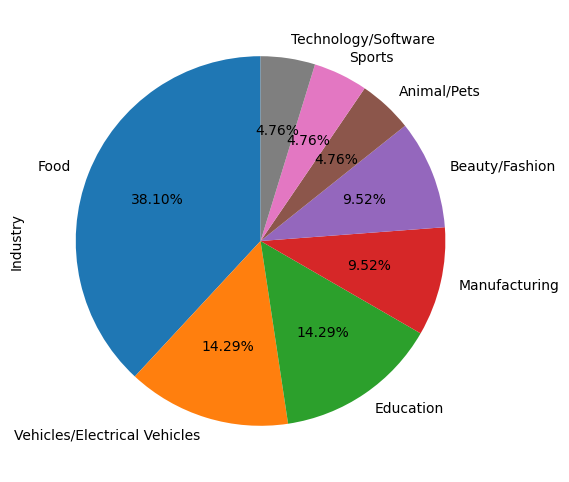

In [ ]:
# Plotting the chart
plt.figure(figsize=(12,6))
shark_tank[shark_tank['Ashneer Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False).plot.pie(autopct='%1.2f%%', startangle=90)

In [ ]:
# Viewing the DataFrame
tmpdf = shark_tank.loc[shark_tank['Ashneer Investment Amount']>0] [["Startup Name","Ashneer Investment Amount","Ashneer Investment Equity"]].sort_values(by="Ashneer Investment Equity")
tmpdf

,Startup Name,Ashneer Investment Amount,Ashneer Investment Equity
56,Otua,1.00,1.00
30,EventBeep,10.00,1.00
22,BeyondSnack,25.00,1.25
68,HairOriginals,20.00,1.33
46,BambooIndia,25.00,1.75
64,INACAN,20.00,2.00
18,RaisingSuperstars,50.00,2.00
59,WeSTOCK,15.00,2.50
39,TheYarnBazaar,25.00,2.50
3,TagzFoods,70.00,2.75


In [ ]:
# Visualization Code
tmpdf = shark_tank.loc[shark_tank['Ashneer Investment Amount']>0] [["Startup Name","Ashneer Investment Amount","Ashneer Investment Equity"]].sort_values(by="Ashneer Investment Equity")
fig = px.bar(tmpdf, x="Ashneer Investment Equity", y='Ashneer Investment Amount', color="Startup Name", template='plotly', title="<b>Total equity received by Ashneer (in %) for investment (in lakhs)</b>", text=tmpdf['Ashneer Investment Amount'].map(int).map(str) + " lakhs")
fig.update_layout(dict(xaxis = dict(type="category")))
fig.show()

* *Ashneer's portfolio has more food industry based startups than any other sharks.*

####*NAMITA'S INVESTMENT*

In [ ]:
# Finding the count of various Industries
shark_tank[shark_tank['Namita Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False)

Beauty/Fashion          13
Medical/Health          12
Food                    11
Manufacturing            8
Services                 6
Technology/Software      5
Education                3
Furnishing/Household     3
Sports                   2
Animal/Pets              1
Entertainment            1
Agriculture              1
Name: Industry, dtype: int64

<Axes: ylabel='Industry'>

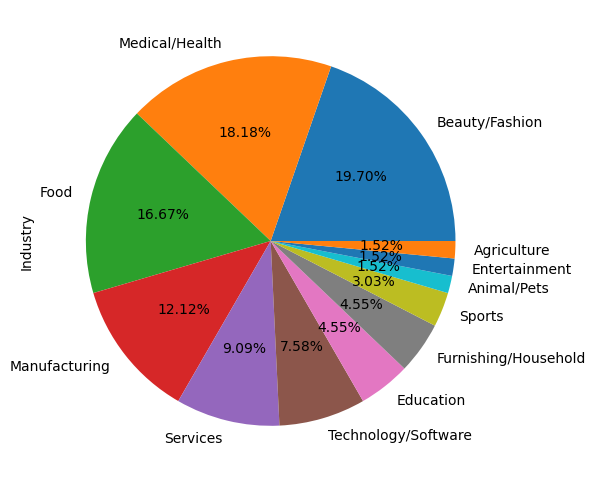

In [ ]:
# Plotting the chart
plt.figure(figsize=(12,6))
shark_tank[shark_tank['Namita Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False).plot.pie(autopct='%1.2f%%')

* *Namita has more beauty and Fashion industry based startups than food based startups.*

In [ ]:
# Viewing the DataFrame
tmpdf = shark_tank.loc[shark_tank['Namita Investment Amount']>0] [["Startup Name","Namita Investment Amount","Namita Investment Equity"]].sort_values(by="Namita Investment Equity")
tmpdf

,Startup Name,Namita Investment Amount,Namita Investment Equity
159,Stage,50.00,0.200
209,Snitch,30.00,0.300
240,MindPeers,17.66,0.330
306,Rubans,33.33,0.333
279,GROWiT,25.00,0.500
...,...,...,...
294,LondonBubble,75.00,15.000
16,Menstrupedia,50.00,20.000
160,Girgit,20.00,20.000
107,ColourMeMad-CMM,40.00,25.000


In [ ]:
# Visualization Code
tmpdf = shark_tank.loc[shark_tank['Namita Investment Amount']>0] [["Startup Name","Namita Investment Amount","Namita Investment Equity"]].sort_values(by="Namita Investment Equity")
fig = px.bar(tmpdf, x="Namita Investment Equity", y='Namita Investment Amount', color="Startup Name", template='plotly', title="<b>Total equity received by Namita (in %) for investment (in lakhs)</b>", text=tmpdf['Namita Investment Amount'].map(int).map(str) + " lakhs")
fig.update_layout(dict(xaxis = dict(type="category")))
fig.show()

####*ANUPAM'S INVESTMENT*

In [ ]:
# Finding the count of various Industries
shark_tank[shark_tank['Anupam Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False)

Food                            13
Beauty/Fashion                  11
Manufacturing                    7
Medical/Health                   6
Technology/Software              3
Vehicles/Electrical Vehicles     2
Education                        2
Animal/Pets                      1
Sports                           1
Electronics                      1
Liquor/Beverages                 1
Services                         1
Furnishing/Household             1
Name: Industry, dtype: int64

<Axes: ylabel='Industry'>

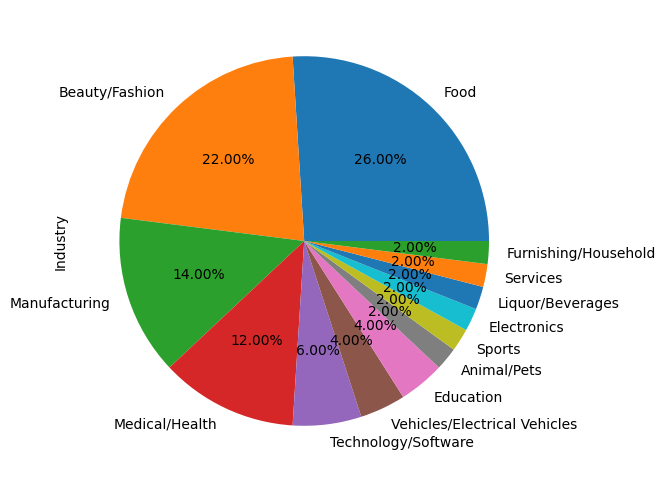

In [ ]:
# Plotting the chart
plt.figure(figsize=(12,6))
shark_tank[shark_tank['Anupam Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False).plot.pie(autopct='%1.2f%%')

* *Food also dominate the chart like Ashneer's followed by Beauty/Fashion in Anupam's investment portfolio.*

In [ ]:
# Viewing the DataFrame
tmpdf = shark_tank.loc[shark_tank['Anupam Investment Amount']>0] [["Startup Name","Anupam Investment Amount","Anupam Investment Equity"]].sort_values(by="Anupam Investment Equity")
tmpdf

,Startup Name,Anupam Investment Amount,Anupam Investment Equity
209,Snitch,30.000000,0.300
281,Trunome,37.500000,0.500
12,RevampMoto,50.000000,0.750
86,WattTechnovations,0.000253,1.000
274,Pharmallama,40.000000,1.000
230,UnStop,50.000000,1.000
37,Annie,35.000000,1.000
219,PadCare,25.000000,1.000
80,SunfoxTechnologies,20.000000,1.200
68,HairOriginals,20.000000,1.330


In [ ]:
# Visualization Code
tmpdf = shark_tank.loc[shark_tank['Anupam Investment Amount']>0] [["Startup Name","Anupam Investment Amount","Anupam Investment Equity"]].sort_values(by="Anupam Investment Equity")
fig = px.bar(tmpdf, x="Anupam Investment Equity", y='Anupam Investment Amount', color="Startup Name", template='plotly', title="<b>Total equity received by Anupam (in %) for investment (in lakhs)</b>", text=tmpdf['Anupam Investment Amount'].map(int).map(str) + " lakhs")
fig.update_layout(dict(xaxis = dict(type="category")))
fig.show()

####*VINEETA'S INVESTMENT*

In [ ]:
# Finding the count of various Industries
shark_tank[shark_tank['Vineeta Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False)

Food                            17
Beauty/Fashion                  10
Medical/Health                   3
Manufacturing                    3
Vehicles/Electrical Vehicles     2
Liquor/Beverages                 2
Furnishing/Household             2
Sports                           1
Electronics                      1
Technology/Software              1
Services                         1
Name: Industry, dtype: int64

<Axes: ylabel='Industry'>

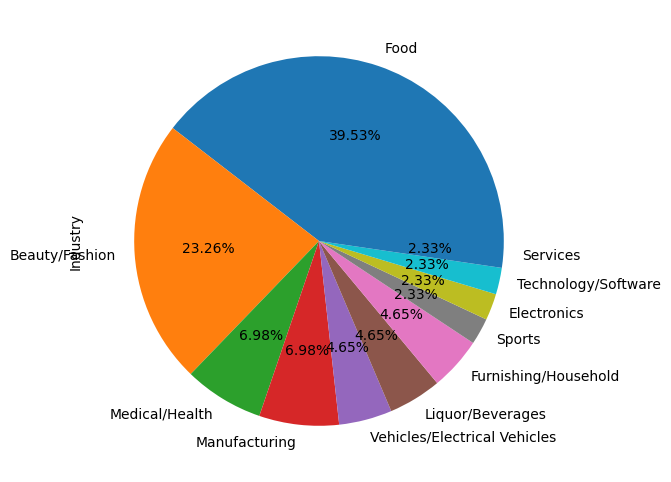

In [ ]:
# Plotting the chart
plt.figure(figsize=(12,6))
shark_tank[shark_tank['Vineeta Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False).plot.pie(autopct='%1.2f%%')

* *Vineeta's portfolio has 39.53% Food based start-ups followed by 23.26% Beauty/Fashion based start-ups.*

In [ ]:
# Viewing the DataFrame
tmpdf = shark_tank.loc[shark_tank['Vineeta Investment Amount']>0] [["Startup Name","Vineeta Investment Amount","Vineeta Investment Equity"]].sort_values(by="Vineeta Investment Equity")
tmpdf

,Startup Name,Vineeta Investment Amount,Vineeta Investment Equity
209,Snitch,30.00,0.300
240,MindPeers,17.66,0.330
306,Rubans,33.33,0.333
281,Trunome,37.50,0.500
255,Perfora,26.66,0.833
219,PadCare,25.00,1.000
176,Paradyes,32.50,1.000
80,SunfoxTechnologies,20.00,1.200
300,ThePlatedProject,25.00,1.250
283,What'sUpWellness,20.00,1.586


In [ ]:
# Visualization Code
tmpdf = shark_tank.loc[shark_tank['Vineeta Investment Amount']>0] [["Startup Name","Vineeta Investment Amount","Vineeta Investment Equity"]].sort_values(by="Vineeta Investment Equity")
fig = px.bar(tmpdf, x="Vineeta Investment Equity", y='Vineeta Investment Amount', color="Startup Name", template='plotly', title="<b>Total equity received by Vineeta (in %) for investment (in lakhs)</b>", text=tmpdf['Vineeta Investment Amount'].map(int).map(str) + " lakhs")
fig.update_layout(dict(xaxis = dict(type="category")))
fig.show()

####*AMAN'S INVESTMENT*

In [ ]:
# Finding the count of various Industries
shark_tank[shark_tank['Aman Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False)

Food                            18
Beauty/Fashion                  14
Medical/Health                   8
Manufacturing                    7
Technology/Software              7
Services                         7
Vehicles/Electrical Vehicles     3
Education                        3
Liquor/Beverages                 2
Electronics                      1
Animal/Pets                      1
Entertainment                    1
Name: Industry, dtype: int64

<Axes: ylabel='Industry'>

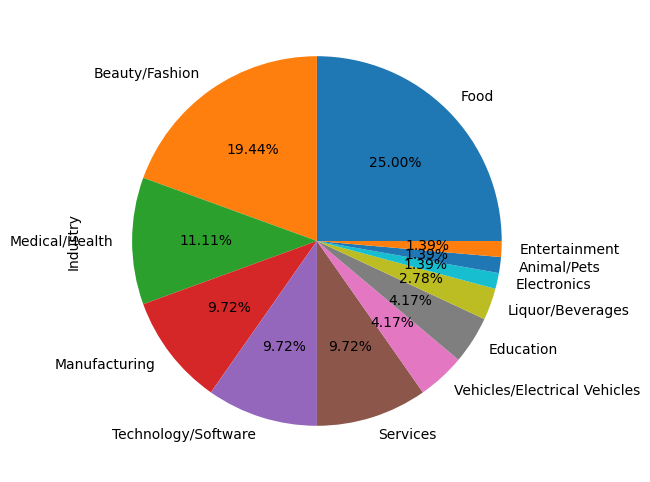

In [ ]:
# Plotting the chart
plt.figure(figsize=(12,6))
shark_tank[shark_tank['Aman Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False).plot.pie(autopct='%1.2f%%')

* *Aman has more Food and Beauty/Fashion based start-ups in his portfolio followed by other groups.*

In [ ]:
# Viewing the DataFrame
tmpdf = shark_tank.loc[shark_tank['Aman Investment Amount']>0] [["Startup Name","Aman Investment Amount","Aman Investment Equity"]].sort_values(by="Aman Investment Equity")
tmpdf

,Startup Name,Aman Investment Amount,Aman Investment Equity
159,Stage,50.00,0.200
277,Hood,30.00,0.270
209,Snitch,30.00,0.300
240,MindPeers,17.66,0.330
306,Rubans,33.33,0.333
...,...,...,...
228,Manetain,75.00,10.000
33,Farda,15.00,10.000
72,NamhyaFoods,50.00,10.000
213,Dabble,15.00,10.000


In [ ]:
# Visualization Code
tmpdf = shark_tank.loc[shark_tank['Aman Investment Amount']>0] [["Startup Name","Aman Investment Amount","Aman Investment Equity"]].sort_values(by="Aman Investment Equity")
fig = px.bar(tmpdf, x="Aman Investment Equity", y='Aman Investment Amount', color="Startup Name", template='plotly', title="<b>Total equity received by Aman (in %) for investment (in lakhs)</b>", text=tmpdf['Aman Investment Amount'].map(int).map(str) + " lakhs")
fig.update_layout(dict(xaxis = dict(type="category")))
fig.show()

####*PEYUSH'S INVESTMENT*

In [ ]:
# Finding the count of various Industries
shark_tank[shark_tank['Peyush Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False)

Medical/Health                  11
Manufacturing                   11
Food                             8
Technology/Software              8
Services                         8
Beauty/Fashion                   7
Education                        3
Agriculture                      2
Sports                           2
Liquor/Beverages                 2
Furnishing/Household             2
Animal/Pets                      1
Hardware                         1
Entertainment                    1
Vehicles/Electrical Vehicles     1
Name: Industry, dtype: int64

<Axes: ylabel='Industry'>

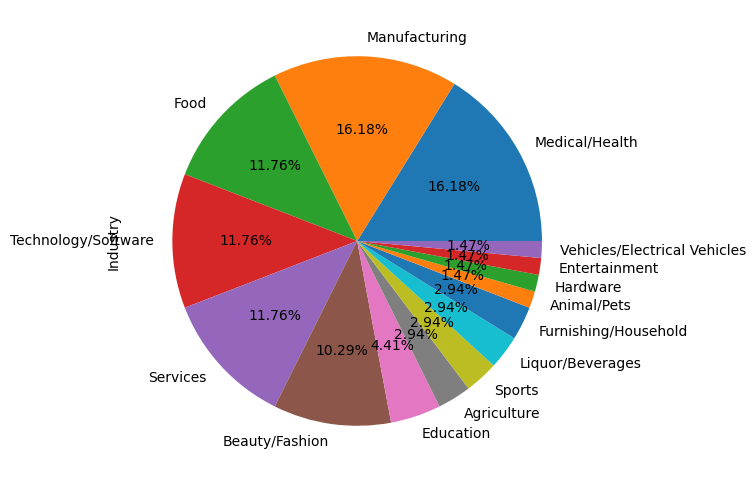

In [ ]:
# Plotting the chart
plt.figure(figsize=(12,6))
shark_tank[shark_tank['Peyush Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False).plot.pie(autopct='%1.2f%%')

* *Peyush's portfolio is dominated by Medical/Health, Manufacturing, Technology/Software and Food.*

In [ ]:
# Viewing the DataFrame
tmpdf = shark_tank.loc[shark_tank['Peyush Investment Amount']>0] [["Startup Name","Peyush Investment Amount","Peyush Investment Equity"]].sort_values(by="Peyush Investment Equity")
tmpdf

,Startup Name,Peyush Investment Amount,Peyush Investment Equity
159,Stage,50.0,0.20
277,Hood,30.0,0.27
209,Snitch,30.0,0.30
281,Trunome,37.5,0.50
279,GROWiT,25.0,0.50
...,...,...,...
53,RoadBounce,80.0,20.00
44,PNT,25.0,25.00
77,KGAgrotech,10.0,40.00
82,IsakFragrances,50.0,50.00


In [ ]:
# Visualization Code
tmpdf = shark_tank.loc[shark_tank['Peyush Investment Amount']>0] [["Startup Name","Peyush Investment Amount","Peyush Investment Equity"]].sort_values(by="Peyush Investment Equity")
fig = px.bar(tmpdf, x="Peyush Investment Equity", y='Peyush Investment Amount', color="Startup Name", template='plotly', title="<b>Total equity received by Peyush (in %) for investment (in lakhs)</b>", text=tmpdf['Peyush Investment Amount'].map(int).map(str) + " lakhs")
fig.update_layout(dict(xaxis = dict(type="category")))
fig.show()

####*GHAZAL'S INVESTMENT*

In [ ]:
# Finding the count of various Industries
shark_tank[shark_tank['Ghazal Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False)

Food              3
Medical/Health    2
Manufacturing     2
Beauty/Fashion    1
Name: Industry, dtype: int64

<Axes: ylabel='Industry'>

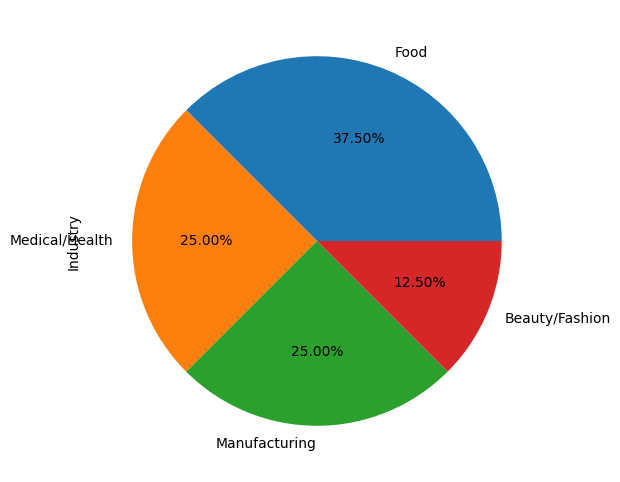

In [ ]:
# Plotting the chart
plt.figure(figsize=(12,6))
shark_tank[shark_tank['Ghazal Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False).plot.pie(autopct='%1.2f%%')

* *Ghazal's investment portfolio consists of four different industries. Among all the sharks, she has the most uncluttered investment basket.*

In [ ]:
# Viewing the DataFrame
tmpdf = shark_tank.loc[shark_tank['Ghazal Investment Amount']>0] [["Startup Name","Ghazal Investment Amount","Ghazal Investment Equity"]].sort_values(by="Ghazal Investment Equity")
tmpdf

,Startup Name,Ghazal Investment Amount,Ghazal Investment Equity
86,WattTechnovations,0.000253,1.0
80,SunfoxTechnologies,20.000000,1.2
89,HumpyA2,33.330000,5.0
111,NomadFoodProject,10.000000,5.0
122,WitBlox,30.000000,5.0
92,WakaoFoods,25.000000,7.0
91,GoldSafeSolutions,16.660000,10.0
76,TheSassBar,25.000000,17.5


In [ ]:
# Visualization Code
tmpdf = shark_tank.loc[shark_tank['Ghazal Investment Amount']>0] [["Startup Name","Ghazal Investment Amount","Ghazal Investment Equity"]].sort_values(by="Ghazal Investment Equity")
fig = px.bar(tmpdf, x="Ghazal Investment Equity", y='Ghazal Investment Amount', color="Startup Name", template='plotly', title="<b>Total equity received by Ghazal (in %) for investment (in lakhs)</b>", text=tmpdf['Ghazal Investment Amount'].map(int).map(str) + " lakhs")
fig.update_layout(dict(xaxis = dict(type="category")))
fig.show()

####*AMIT'S INVESTMENT*

In [ ]:
# Finding the count of various Industries
shark_tank[shark_tank['Amit Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False)

Food                            6
Beauty/Fashion                  5
Medical/Health                  3
Services                        2
Technology/Software             2
Manufacturing                   1
Furnishing/Household            1
Vehicles/Electrical Vehicles    1
Name: Industry, dtype: int64

<Axes: ylabel='Industry'>

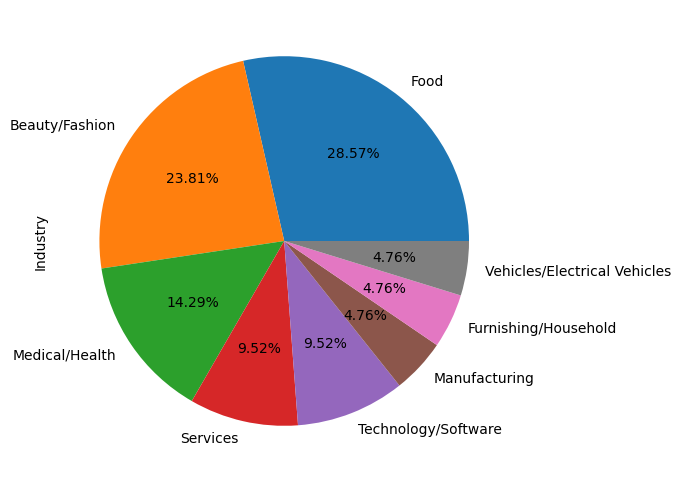

In [ ]:
# Plotting the chart
plt.figure(figsize=(12,6))
shark_tank[shark_tank['Amit Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False).plot.pie(autopct='%1.2f%%')

* *Amit's portfolio is dominated by Food and Beauty/Fashion.*

In [ ]:
# Viewing the DataFrame
tmpdf = shark_tank.loc[shark_tank['Amit Investment Amount']>0] [["Startup Name","Amit Investment Amount","Amit Investment Equity"]].sort_values(by="Amit Investment Equity")
tmpdf

,Startup Name,Amit Investment Amount,Amit Investment Equity
313,maisha,10.00,1.0000
274,Pharmallama,40.00,1.0000
230,UnStop,50.00,1.0000
273,GladFul,16.66,1.1666
290,Aadvik,15.00,1.5000
271,nawgati,33.50,1.5000
311,Sahayatha,20.00,2.0000
314,NishHair,100.00,2.0000
289,funngro,25.00,2.0800
266,Hornback,50.00,2.5000


In [ ]:
# Visualization Code
tmpdf = shark_tank.loc[shark_tank['Amit Investment Amount']>0] [["Startup Name","Amit Investment Amount","Amit Investment Equity"]].sort_values(by="Amit Investment Equity")
fig = px.bar(tmpdf, x="Amit Investment Equity", y='Amit Investment Amount', color="Startup Name", template='plotly', title="<b>Total equity received by Amit (in %) for investment (in lakhs)</b>", text=tmpdf['Amit Investment Amount'].map(int).map(str) + " lakhs")
fig.update_layout(dict(xaxis = dict(type="category")))
fig.show()

####*GUEST'S INVESTMENT*

In [ ]:
# Printing the Guest's Name
print(f"The Guest's name is {shark_tank[shark_tank['Guest Name']=='Vikas']['Guest Name'].iloc[0]}.")

The Guest's name is Vikas.


In [ ]:
# Finding the count of various Industries
shark_tank[shark_tank['Guest Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False)

Beauty/Fashion      1
Liquor/Beverages    1
Name: Industry, dtype: int64

<Axes: ylabel='Industry'>

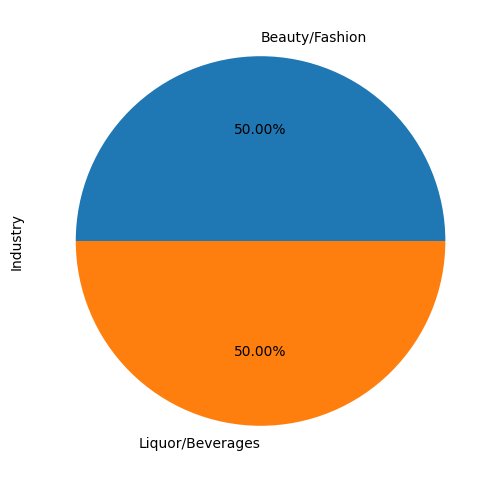

In [ ]:
# Plotting the chart
plt.figure(figsize=(12,6))
shark_tank[shark_tank['Guest Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False).plot.pie(autopct='%1.2f%%')

* *Guest's portfolio is equally divided between Beauty/Fashion and Liquor/Beverages.*

In [ ]:
# Viewing the DataFrame
tmpdf = shark_tank.loc[shark_tank['Guest Investment Amount']>0] [["Startup Name","Guest Investment Amount","Guest Investment Equity"]].sort_values(by="Guest Investment Equity")
tmpdf

,Startup Name,Guest Investment Amount,Guest Investment Equity
317,TAC,40.5,0.5
318,Naara-Aaba,25.0,2.5


In [ ]:
# Visualization Code
tmpdf = shark_tank.loc[shark_tank['Guest Investment Amount']>0] [["Startup Name","Guest Investment Amount","Guest Investment Equity"]].sort_values(by="Guest Investment Equity")
fig = px.bar(tmpdf, x="Guest Investment Equity", y='Guest Investment Amount', color="Startup Name", template='plotly', title="<b>Total equity received by Guest (in %) for investment (in lakhs)</b>", text=tmpdf['Guest Investment Amount'].map(int).map(str) + " lakhs")
fig.update_layout(dict(xaxis = dict(type="category")))
fig.show()

## **Number of sharks in a deal**

1.0    42%
2.0    31%
3.0    16%
4.0     7%
5.0     5%
Name: Number of sharks in deal, dtype: object


<Axes: xlabel='Number of sharks in deal', ylabel='count'>

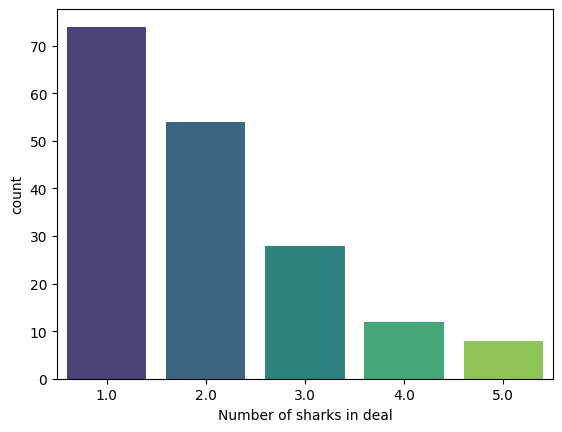

In [ ]:
# Visualization Code
print(round(shark_tank['Number of sharks in deal'].value_counts(normalize=True) * 100).astype(str).str.replace('.0','%'))
sns.countplot(data=shark_tank,x='Number of sharks in deal',palette='viridis')

In [ ]:
# The deal where more than or equal to 5 sharks were involved
tmdf = shark_tank[shark_tank['Number of sharks in deal'] >= 5][['Startup Name','Total Deal Amount','Total Deal Equity']]
tmdf

,Startup Name,Total Deal Amount,Total Deal Equity
15,SkippiIcePops,100.0,15.0
50,FindYourKicksIndia,50.0,25.0
64,INACAN,100.0,10.0
80,SunfoxTechnologies,100.0,6.0
209,Snitch,150.0,1.5
239,Mahantam,30.0,20.0
274,Pharmallama,200.0,5.0
311,Sahayatha,100.0,10.0


## **Total Amount Asked by the Pitchers**

In [ ]:
# Amount asked by the pitchers
print(format_currency(shark_tank['Original Ask Amount'].sum()/100,'INR',locale='en_IN').replace('.00',''), 'crores')

₹541.41 crores


## **Total Amount Invested by the sharks**

In [ ]:
# Amount invested by the sharks
print(format_currency(shark_tank['Total Deal Amount'].sum()/100,'INR',locale='en_IN').replace('.00',''), 'crores')

₹110.06 crores


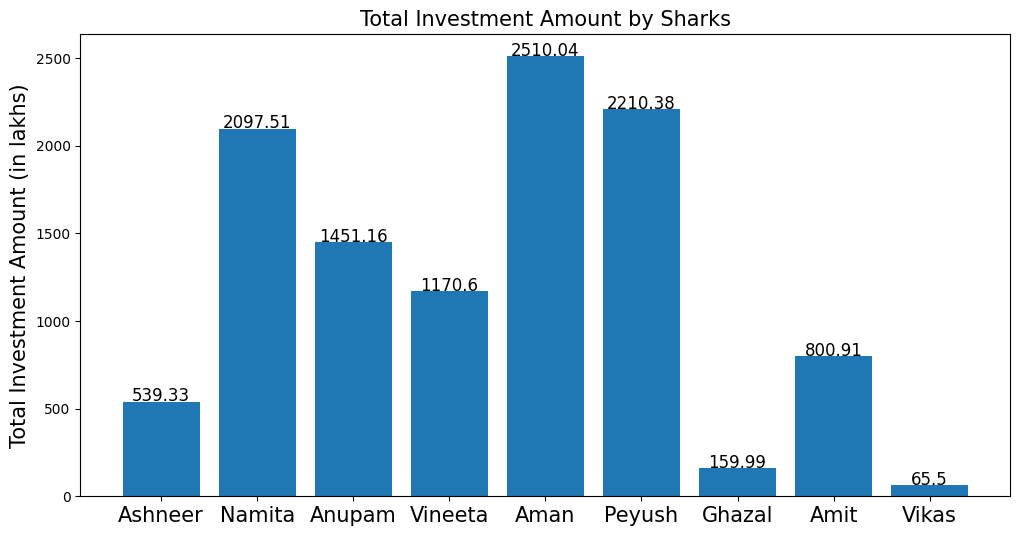

In [ ]:
# Visualization Code
amount = [shark_tank['Ashneer Investment Amount'].sum(), shark_tank['Namita Investment Amount'].sum(), shark_tank['Anupam Investment Amount'].sum(), shark_tank['Vineeta Investment Amount'].sum(),
    shark_tank['Aman Investment Amount'].sum(), shark_tank['Peyush Investment Amount'].sum(), shark_tank['Ghazal Investment Amount'].sum(), shark_tank['Amit Investment Amount'].sum(), shark_tank['Guest Investment Amount'].sum()]
name=['Ashneer','Namita','Anupam','Vineeta','Aman','Peyush','Ghazal','Amit','Vikas']
df = {'Name':name, 'Total Amount':amount }
plt.figure(figsize=(12,6))
plt.bar(df['Name'], df['Total Amount'])
plt.xticks(fontsize=15)
plt.ylabel("Total Investment Amount (in lakhs)",fontsize=15)
for index,d in enumerate(amount):
    plt.text(x=index, y =d+2, s=f"{round(d,2)}", ha = 'center', fontdict=dict(fontsize=12))
plt.title("Total Investment Amount by Sharks", fontsize=15)
plt.show()


## **Total Amount Lent by the Sharks**

In [ ]:
# Amount invested by the sharks
print(format_currency(shark_tank['Total Deal Debt'].sum()/100,'INR',locale='en_IN').replace('.00',''), 'crores')

₹18.11 crores


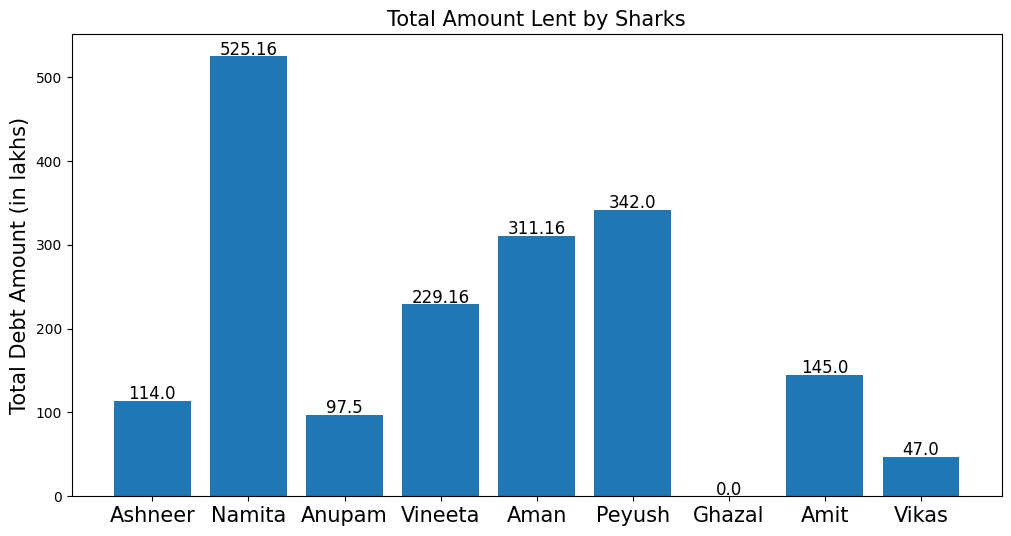

In [ ]:
# Visualization Code
amount = [shark_tank['Ashneer Debt Amount'].sum(), shark_tank['Namita Debt Amount'].sum(), shark_tank['Anupam Debt Amount'].sum(), shark_tank['Vineeta Debt Amount'].sum(),
    shark_tank['Aman Debt Amount'].sum(), shark_tank['Peyush Debt Amount'].sum(), shark_tank['Ghazal Debt Amount'].sum(), shark_tank['Amit Debt Amount'].sum(), shark_tank['Guest Debt Amount'].sum()]
name=['Ashneer','Namita','Anupam','Vineeta','Aman','Peyush','Ghazal','Amit','Vikas']
df = {'Name':name, 'Total Amount':amount }
plt.figure(figsize=(12,6))
plt.bar(df['Name'], df['Total Amount'])
plt.xticks(fontsize=15)
plt.ylabel("Total Debt Amount (in lakhs)",fontsize=15)
for index,d in enumerate(amount):
    plt.text(x=index, y =d+2, s=f"{round(d,2)}", ha = 'center', fontdict=dict(fontsize=12))
plt.title("Total Amount Lent by Sharks", fontsize=15)
plt.show()

## **Portfolio's of Different sharks**

#### *PEYUSH'S PORTFOLIO*

In [ ]:
print("Peyush Bansal's total investments =", shark_tank[shark_tank['Peyush Investment Amount']>0][['Peyush Investment Amount']].count().to_string()[-2:])
print("Investment amount by Peyush =", round(shark_tank['Peyush Investment Amount'].sum()/100, 2), "crores\n")
print("Equity received by Peyush =", round(shark_tank['Peyush Investment Equity'].sum(), 2), "% in different companies\n")
print("Debt/loan amount by Peyush =", round(shark_tank['Peyush Debt Amount'].sum()/100, 2), "crores\n")
print('-'*80)
print(shark_tank.loc[shark_tank['Peyush Investment Amount']>0][["Startup Name","Industry","Peyush Investment Amount"]].reset_index().drop('index',axis=1).head(30))

Peyush Bansal's total investments = 68
Investment amount by Peyush = 22.1 crores

Equity received by Peyush = 422.11 % in different companies

Debt/loan amount by Peyush = 3.42 crores

--------------------------------------------------------------------------------
          Startup Name             Industry  Peyush Investment Amount
0   VivalyfInnovations       Medical/Health                 28.000000
1                Ariro        Manufacturing                 25.000000
2              Nuutjob       Beauty/Fashion                  8.330000
3             Meatyour                 Food                 10.000000
4            EventBeep            Education                 10.000000
5                 LOKA  Technology/Software                 13.330000
6                Annie            Education                 35.000000
7           Carragreen        Manufacturing                 25.000000
8        TheYarnBazaar        Manufacturing                 25.000000
9                  PNT  Technology

#### *AMAN'S PORTFOLIO*

In [ ]:
print("Aman Gupta's total investments =", shark_tank[shark_tank['Aman Investment Amount']>0][['Aman Investment Amount']].count().to_string()[-2:])
print("Investment amount by Aman =", round(shark_tank['Aman Investment Amount'].sum()/100, 2), "crores\n")
print("Equity received by Aman =", round(shark_tank['Aman Investment Equity'].sum(), 2), "% in different companies\n")
print("Debt/loan amount by Aman =", round(shark_tank['Aman Debt Amount'].sum()/100, 2), "crores\n")
print('-'*80)
print(shark_tank.loc[shark_tank['Aman Investment Amount']>0][["Startup Name","Industry","Aman Investment Amount"]].reset_index().drop('index',axis=1).head(30))

Aman Gupta's total investments = 72
Investment amount by Aman = 25.1 crores

Equity received by Aman = 260.93 % in different companies

Debt/loan amount by Aman = 3.11 crores

--------------------------------------------------------------------------------
          Startup Name                      Industry  Aman Investment Amount
0        BluePineFoods                          Food               25.000000
1            Peeschute                Beauty/Fashion               75.000000
2               Bummer                Beauty/Fashion               37.500000
3           RevampMoto  Vehicles/Electrical Vehicles               50.000000
4        SkippiIcePops                          Food               20.000000
5    RaisingSuperstars                     Education               50.000000
6               Kavach                     Education                2.500000
7          BeyondSnack                          Food               25.000000
8                Altor                 Manufacturi

#### *GHAZAL'S PORTFOLIO*

In [ ]:
print("Ghazal Alagh's total investments =", shark_tank[shark_tank['Ghazal Investment Amount']>0][['Ghazal Investment Amount']].count().to_string()[-2:])
print("Investment amount by Ghazal =", round(shark_tank['Ghazal Investment Amount'].sum()/100, 2), "crores\n")
print("Equity received by Ghazal =", round(shark_tank['Ghazal Investment Equity'].sum(), 2), "% in different companies\n")
print("Debt/loan amount by Ghazal =", round(shark_tank['Ghazal Debt Amount'].sum()/100, 2), "crores\n")
print('-'*80)
print(shark_tank.loc[shark_tank['Ghazal Investment Amount']>0][["Startup Name","Industry","Ghazal Investment Amount"]].reset_index().drop('index',axis=1))

Ghazal Alagh's total investments =  8
Investment amount by Ghazal = 1.6 crores

Equity received by Ghazal = 51.7 % in different companies

Debt/loan amount by Ghazal = 0.0 crores

--------------------------------------------------------------------------------
         Startup Name        Industry  Ghazal Investment Amount
0          TheSassBar  Beauty/Fashion                 25.000000
1  SunfoxTechnologies  Medical/Health                 20.000000
2   WattTechnovations  Medical/Health                  0.000253
3             HumpyA2            Food                 33.330000
4   GoldSafeSolutions   Manufacturing                 16.660000
5          WakaoFoods            Food                 25.000000
6    NomadFoodProject            Food                 10.000000
7             WitBlox   Manufacturing                 30.000000


In [ ]:
def str_splitter(s):
    # Split the input string using '/' as the delimiter
    s_split = s.split('/')

    # Check if the first part of the split string is 'Vehicles'
    if s_split[0] == 'Vehicles':
        # If it is, return the second part of the split string
        return s_split[1]
    else:
        # If it's not, return the string itself
        return s

In [ ]:
# Applying the function to Industry Column
shark_tank['Industry'] = shark_tank['Industry'].apply(str_splitter)

#### *ASHNEER'S PORTFOLIO*

In [ ]:
print("Ashneer Grover's total investments =", shark_tank[shark_tank['Ashneer Investment Amount']>0][['Ashneer Investment Amount']].count().to_string()[-2:])
print("Investment amount by Ashneer =", round(shark_tank['Ashneer Investment Amount'].sum()/100, 2), "crores\n")
print("Equity received by Ashneer =", round(shark_tank['Ashneer Investment Equity'].sum(), 2), "% in different companies\n")
print("Debt/loan amount by Ashneer =", round(shark_tank['Ashneer Debt Amount'].sum()/100, 2), "crores\n")
print('-'*80)
print(shark_tank.loc[shark_tank['Ashneer Investment Amount']>0][["Startup Name","Industry","Ashneer Investment Amount"]].reset_index().drop('index',axis=1))

Ashneer Grover's total investments = 21
Investment amount by Ashneer = 5.39 crores

Equity received by Ashneer = 93.24 % in different companies

Debt/loan amount by Ashneer = 1.14 crores

--------------------------------------------------------------------------------
          Startup Name             Industry  Ashneer Investment Amount
0        BluePineFoods                 Food                      25.00
1         BoozScooters  Electrical Vehicles                      20.00
2            TagzFoods                 Food                      70.00
3        SkippiIcePops                 Food                      20.00
4    RaisingSuperstars            Education                      50.00
5          BeyondSnack                 Food                      25.00
6         MotionBreeze  Electrical Vehicles                      30.00
7            EventBeep            Education                      10.00
8        TheYarnBazaar        Manufacturing                      25.00
9          BambooIndi

#### *NAMITA'S PORTFOLIO*

In [ ]:
print("Namita Thapar's Total Investments =", shark_tank[shark_tank['Namita Investment Amount']>0][['Namita Investment Amount']].count().to_string()[-2:])
print("Investment amount by Namita =", round(shark_tank['Namita Investment Amount'].sum()/100, 2), "crores\n")
print("Equity received by Namita =", round(shark_tank['Namita Investment Equity'].sum(), 2), "% in different companies\n")
print("Debt/loan amount by Namita =", round(shark_tank['Namita Debt Amount'].sum()/100, 2), "crores\n")
print('-'*80)
print(shark_tank.loc[shark_tank['Namita Investment Amount']>0][["Startup Name","Industry","Namita Investment Amount"]].reset_index().drop('index',axis=1).head(30))

Namita Thapar's Total Investments = 66
Investment amount by Namita = 20.98 crores

Equity received by Namita = 301.59 % in different companies

Debt/loan amount by Namita = 5.25 crores

--------------------------------------------------------------------------------
          Startup Name        Industry  Namita Investment Amount
0          JhaJiAchaar            Food                 28.300000
1               Bummer  Beauty/Fashion                 37.500000
2        SkippiIcePops            Food                 20.000000
3         Menstrupedia       Education                 50.000000
4                Altor   Manufacturing                 25.000000
5              Nuutjob  Beauty/Fashion                  8.330000
6                Farda  Beauty/Fashion                 15.000000
7                 Auli  Beauty/Fashion                 75.000000
8                Annie       Education                 35.000000
9      TheRenalProject  Medical/Health                 50.000000
10             Coc

#### *ANUPAM'S PORTFOLIO*

In [ ]:
print("Anupam Mittal's total investments =", shark_tank[shark_tank['Anupam Investment Amount']>0][['Anupam Investment Amount']].count().to_string()[-2:])
print("Investment amount by Anupam =", round(shark_tank['Anupam Investment Amount'].sum()/100, 2), "crores\n")
print("Equity received by Anupam =", round(shark_tank['Anupam Investment Equity'].sum(), 2), "% in different companies\n")
print("Debt/loan amount by Anupam =", round(shark_tank['Anupam Debt Amount'].sum()/100, 2), "crores\n")
print('-'*80)
print(shark_tank.loc[shark_tank['Anupam Investment Amount']>0][["Startup Name","Industry","Anupam Investment Amount"]].reset_index().drop('index',axis=1).head(30))

Anupam Mittal's total investments = 50
Investment amount by Anupam = 14.51 crores

Equity received by Anupam = 305.83 % in different companies

Debt/loan amount by Anupam = 0.98 crores

--------------------------------------------------------------------------------
              Startup Name             Industry  Anupam Investment Amount
0         HeartUpMySleeves       Beauty/Fashion                 12.500000
1                    CosIQ       Beauty/Fashion                 25.000000
2               RevampMoto  Electrical Vehicles                 50.000000
3            SkippiIcePops                 Food                 20.000000
4                   Kavach            Education                  2.500000
5       VivalyfInnovations       Medical/Health                 28.000000
6                 Meatyour                 Food                 10.000000
7   ARRCOATSurfaceTextures        Manufacturing                 50.000000
8                     LOKA  Technology/Software                 13.

#### *VINEETA'S PORTFOLIO*

In [ ]:
print("Vineeta Singh's total investments =", shark_tank[shark_tank['Vineeta Investment Amount']>0][['Vineeta Investment Amount']].count().to_string()[-2:])
print("Investment amount by Vineeta =", round(shark_tank['Vineeta Investment Amount'].sum()/100, 2), "crores\n")
print("Equity received by Vineeta =", round(shark_tank['Vineeta Investment Equity'].sum(), 2), "% in different companies\n")
print("Debt/loan amount by Vineeta =", round(shark_tank['Vineeta Debt Amount'].sum()/100, 2), "crores\n")
print('-'*80)
print(shark_tank.loc[shark_tank['Vineeta Investment Amount']>0][["Startup Name","Industry","Vineeta Investment Amount"]].reset_index().drop('index',axis=1).head(30))

Vineeta Singh's total investments = 43
Investment amount by Vineeta = 11.71 crores

Equity received by Vineeta = 242.3 % in different companies

Debt/loan amount by Vineeta = 2.29 crores

--------------------------------------------------------------------------------
          Startup Name              Industry  Vineeta Investment Amount
0        BluePineFoods                  Food                      25.00
1         BoozScooters   Electrical Vehicles                      20.00
2     HeartUpMySleeves        Beauty/Fashion                      12.50
3                 NOCD                  Food                      20.00
4                CosIQ        Beauty/Fashion                      25.00
5          JhaJiAchaar                  Food                      28.30
6        SkippiIcePops                  Food                      20.00
7           Get-A-Whey                  Food                      33.33
8       TheQuirkyNaari        Beauty/Fashion                      17.50
9   SunfoxT

#### *AMIT'S PORTFOLIO*

In [ ]:
print("Amit Jain's total investments =", shark_tank[shark_tank['Amit Investment Amount']>0][['Amit Investment Amount']].count().to_string()[-2:])
print("Investment amount by Amit =", round(shark_tank['Amit Investment Amount'].sum()/100, 2), "crores\n")
print("Equity received by Amit =", round(shark_tank['Amit Investment Equity'].sum(), 2), "% in different companies\n")
print("Debt/loan amount by Amit =", round(shark_tank['Amit Debt Amount'].sum()/100, 2), "crores\n")
print('-'*80)
print(shark_tank.loc[shark_tank['Amit Investment Amount']>0][["Startup Name","Industry","Amit Investment Amount"]].reset_index().drop('index',axis=1).head(30))

Amit Jain's total investments = 21
Investment amount by Amit = 8.01 crores

Equity received by Amit = 109.0 % in different companies

Debt/loan amount by Amit = 1.45 crores

--------------------------------------------------------------------------------
     Startup Name              Industry  Amit Investment Amount
0       InsideFPV         Manufacturing                   18.75
1       Angrakhaa        Beauty/Fashion                   40.00
2       MoppFoods                  Food                   75.00
3          Dobiee                  Food                   72.00
4           Pflow        Medical/Health                   30.00
5          ekatra  Furnishing/Household                   10.00
6       licksters                  Food                   25.00
7      ScrapUncle              Services                   60.00
8          UnStop   Technology/Software                   50.00
9     Cakelicious                  Food                   25.00
10       Hornback   Electrical Vehicles  

#### *GUEST'S PORTFOLIO*

In [ ]:
print("Vikas D. Nahar's total investments =", shark_tank[shark_tank['Guest Investment Amount']>0][['Guest Investment Amount']].count().to_string()[-2:])
print("Investment amount by Vikas =", round(shark_tank['Guest Investment Amount'].sum()/100, 2), "crores\n")
print("Equity received by Vikas =", round(shark_tank['Guest Investment Equity'].sum(), 2), "% in different companies\n")
print("Debt/loan amount by Vikas =", round(shark_tank['Guest Debt Amount'].sum()/100, 2), "crores\n")
print('-'*80)
print(shark_tank.loc[shark_tank['Guest Investment Amount']>0][["Startup Name","Industry","Guest Investment Amount"]].reset_index().drop('index',axis=1).head(30))

Vikas D. Nahar's total investments =  2
Investment amount by Vikas = 0.66 crores

Equity received by Vikas = 3.0 % in different companies

Debt/loan amount by Vikas = 0.47 crores

--------------------------------------------------------------------------------
  Startup Name          Industry  Guest Investment Amount
0          TAC    Beauty/Fashion                     40.5
1   Naara-Aaba  Liquor/Beverages                     25.0


## **Top Investments as per Equity Amount**

In [ ]:
# Displaying the DataFrame
df1 = pd.DataFrame(shark_tank.groupby('Startup Name')['Total Deal Equity'].max().nlargest(15)).reset_index()
df1

,Startup Name,Total Deal Equity
0,Sid07Designs,75.00
1,BoozScooters,50.00
2,IsakFragrances,50.00
3,HammerLifestyle,40.00
4,KGAgrotech,40.00
5,TheSassBar,35.00
6,VivalyfInnovations,33.33
7,GoldSafeSolutions,30.00
8,HeartUpMySleeves,30.00
9,JainShikanji,30.00


In [ ]:
# Visualization Code
fig = px.bar(df1, x="Startup Name", y='Total Deal Equity', color="Startup Name", template='plotly', title="Highest Investment as per Equity percentage", text=df1['Total Deal Equity'].map(int).map(str)+'%')
fig.show()

## **Top investments as per Loan Amount**

In [ ]:
# Displaying the DataFrame
df1 = pd.DataFrame(shark_tank.groupby('Startup Name')['Total Deal Debt'].max().nlargest(15)).reset_index()
df1

,Startup Name,Total Deal Debt
0,Stage,150.0
1,WatchoutWearables,100.0
2,uBreathe,100.0
3,Otua,99.0
4,Wol3D,70.0
5,TAC,69.0
6,maisha,65.0
7,Hood,60.0
8,iMumz,60.0
9,AyuSynk,50.0


In [ ]:
# Visualization Code
fig = px.bar(df1, x="Startup Name", y='Total Deal Debt', color="Startup Name", template='plotly', title="Highest Investment as per loan amount", text=df1['Total Deal Debt'])
fig.show()

## **Total Equity Received By Sharks**

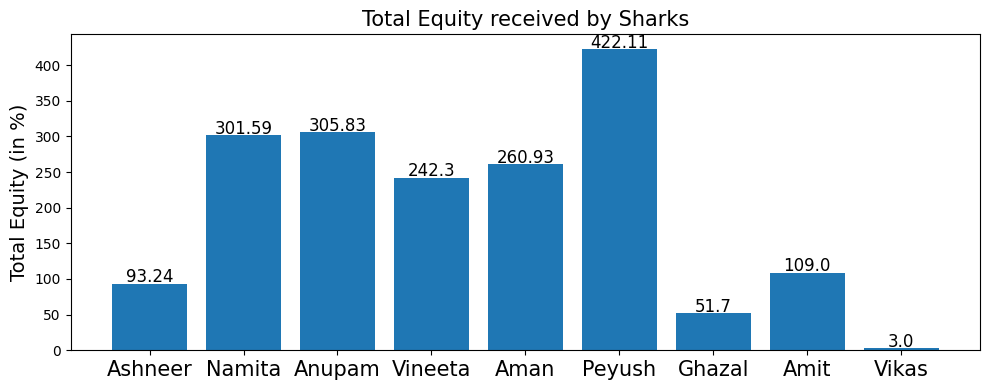

In [ ]:
# Visualization Code
equity = [shark_tank['Ashneer Investment Equity'].sum(), shark_tank['Namita Investment Equity'].sum(), shark_tank['Anupam Investment Equity'].sum(), shark_tank['Vineeta Investment Equity'].sum(),
    shark_tank['Aman Investment Equity'].sum(), shark_tank['Peyush Investment Equity'].sum(), shark_tank['Ghazal Investment Equity'].sum(), shark_tank['Amit Investment Equity'].sum(), shark_tank['Guest Investment Equity'].sum()]
name=['Ashneer','Namita','Anupam','Vineeta','Aman','Peyush','Ghazal','Amit','Vikas']
df = pd.DataFrame({'Name':name, 'Total Equity':equity })
plt.figure(figsize=(10,4))
plt.bar(df['Name'], df['Total Equity'])
plt.xticks(fontsize=15)
plt.ylabel("Total Equity (in %)",fontsize=14)
for index,d in enumerate(equity):
    plt.text(x=index, y =d+2, s=f"{round(d,2)}", ha = 'center', fontdict=dict(fontsize=12))
plt.title("Total Equity received by Sharks", fontsize=15)
plt.tight_layout()
plt.show()

## **Companies who got the same valuation as they requested**

In [ ]:
# Displaying the DataFrame
df3 = pd.DataFrame(shark_tank[shark_tank['Valuation Requested'] == shark_tank['Deal Valuation']][['Startup Name','Valuation Requested','Deal Valuation']].reset_index().drop('index',axis=1))
df3

,Startup Name,Valuation Requested,Deal Valuation
0,Kavach,50.0,50.0
1,BeyondSnack,2000.0,2000.0
2,Cocofit,0.0,0.0
3,WattTechnovations,0.0,0.0
4,TheSimplySalad,300.0,300.0
5,Janitri,4000.0,4000.0
6,NeoMotion,10000.0,10000.0
7,PadCare,2500.0,2500.0
8,Geeani,1000.0,1000.0
9,MindPeers,5300.0,5300.0


## **Some companies were on pre-revenue or didn't have any revenue (as of pitching day)**

In [ ]:
df4 = shark_tank[shark_tank['Yearly Revenue'] == 0]['Startup Name'].reset_index().drop('index',axis=1)
print(f'There were {len(df4)} startups that were on pre-revenue on the pitching day.')
df4

There were 13 startups that were on pre-revenue on the pitching day.


,Startup Name
0,MotionBreeze
1,GoodGoodPiggy
2,JulaaAutomation
3,Scholify
4,Sabjikothi
5,On2Cook
6,Scintiglo
7,Sayonara
8,PMV
9,CureSee


## **Use of WordCloud to visualize the most frequently used keywords in startup names**

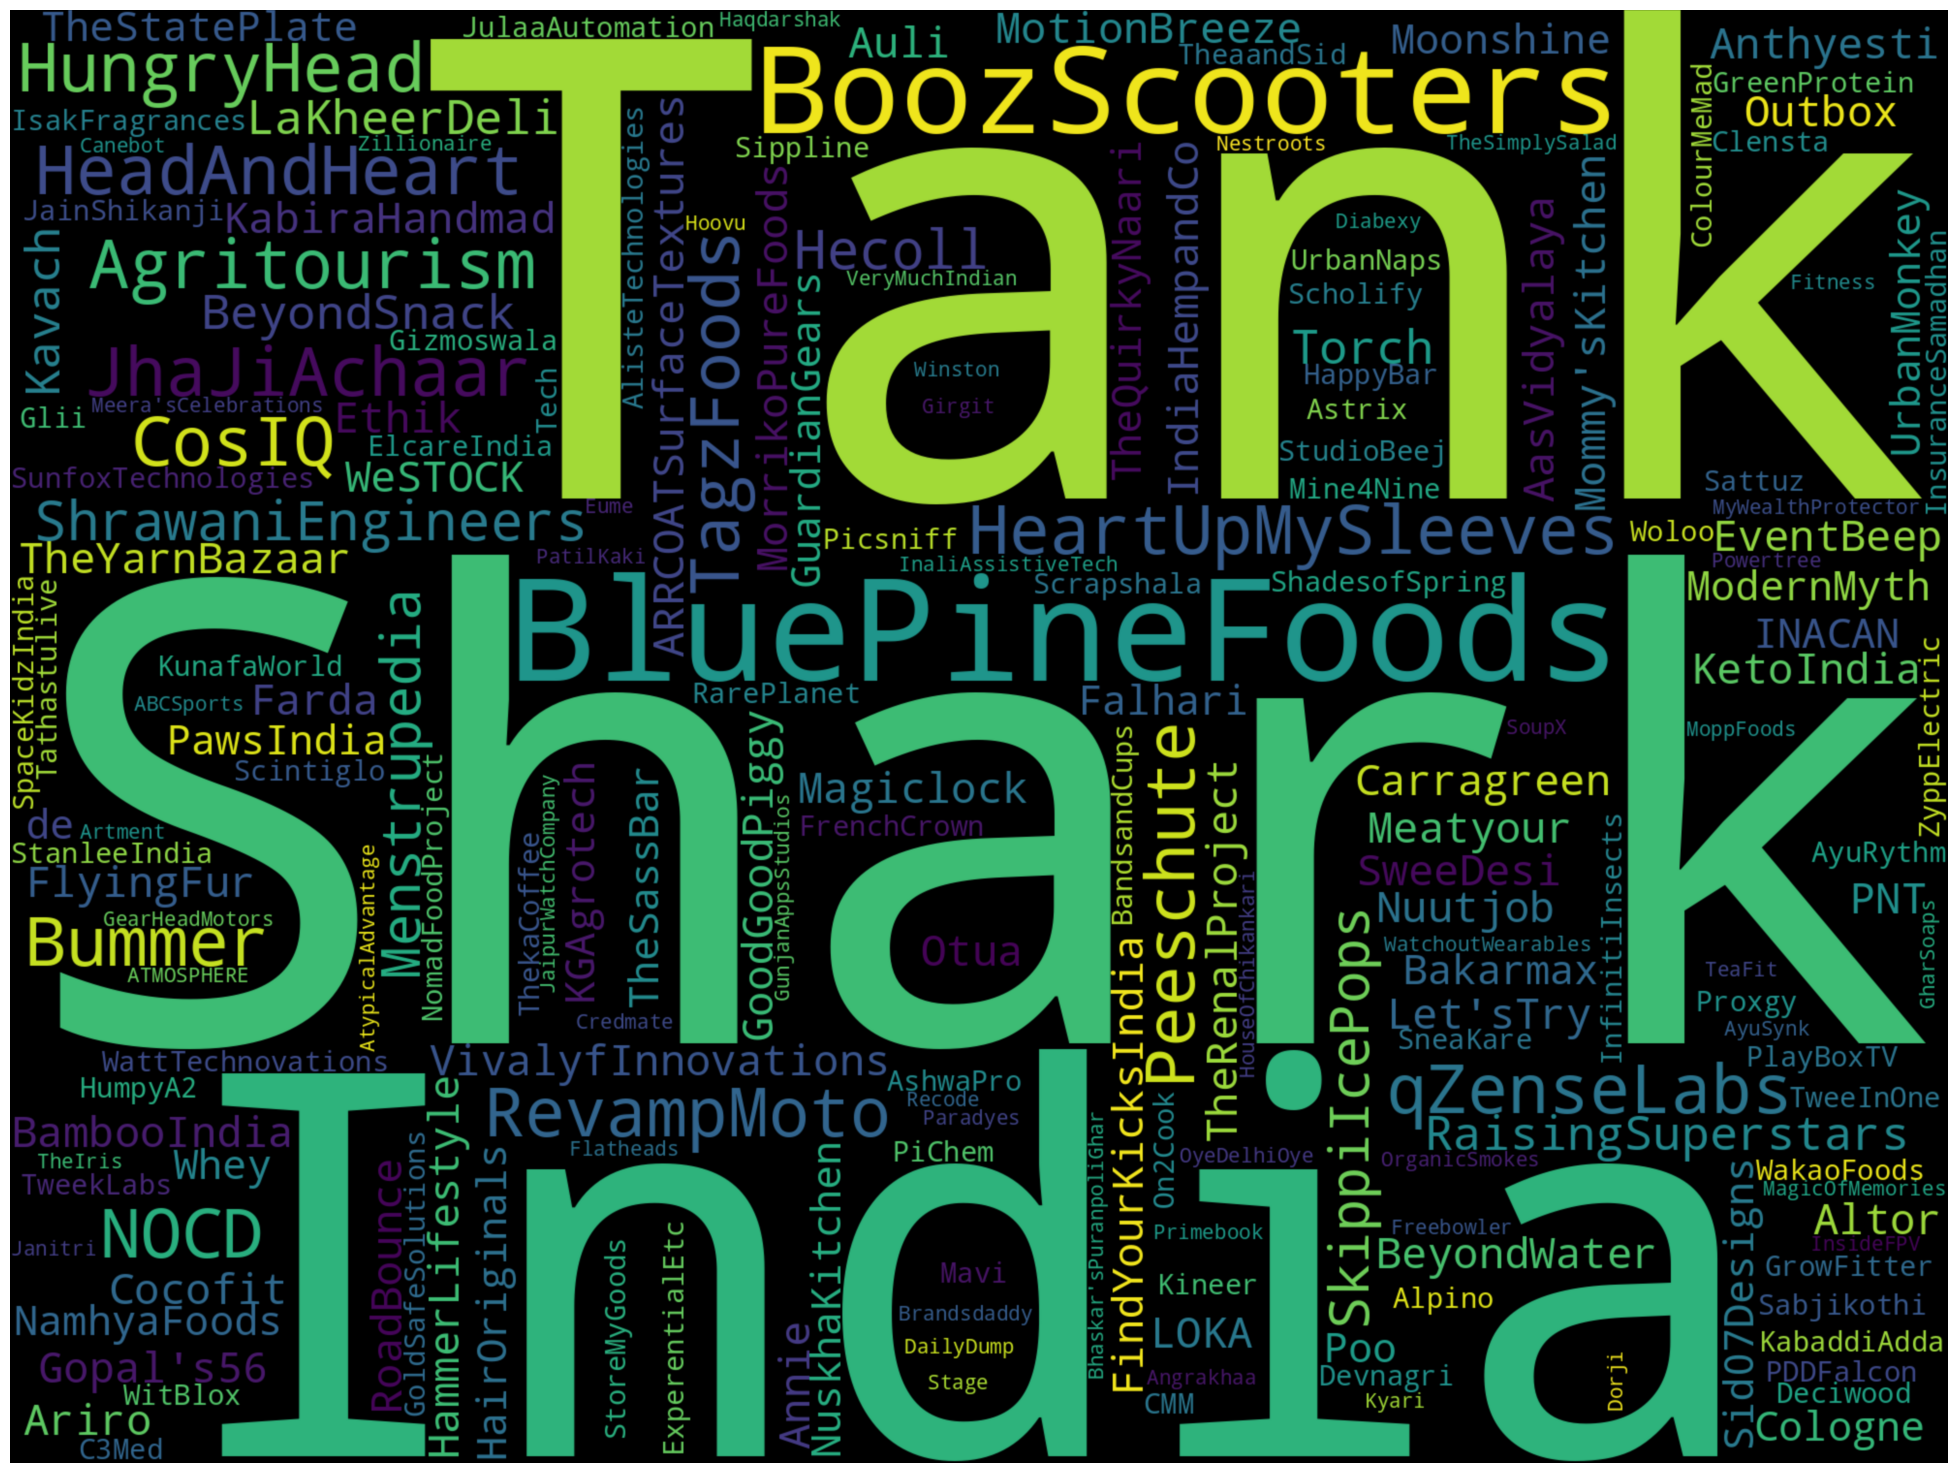

In [ ]:
# Text Data
text = " Shark Tank India ".join(cat for cat in shark_tank['Startup Name'])
stop_words = list(STOPWORDS)

# Create WordCloud object
wordcloud = WordCloud(width=2000, height=1500, stopwords=stop_words, background_color='black', colormap='viridis', collocations=False, random_state=2022).generate(text)

# Display the WordCloud using Matplotlib
plt.figure(figsize=(25,20))
plt.imshow(wordcloud, interpolation='bicubic')
plt.axis("off")
plt.show()

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***